# Latent Space Preference Analysis

This notebook performs Exploratory Data Analysis (EDA) on LLM preference data.
It computes the **unconditional preference direction** in the model's latent space
— identifying the vector that best separates winning responses from losing responses.

### Pipeline Overview

| Phase | Sections | Purpose |
|-------|----------|---------|
| **Infrastructure** | 1–4 | Configuration, data loading, embedding engine, analyzer |
| **Execution** | 5 | Load data, compute embeddings, derive preference directions |
| **Direction Analysis** | 6–9 | Visualize and compare preference directions across experiments |
| **Semantic Interpretation** | 10–14 | Project vocabulary onto directions to interpret *what* the model prefers |

### Key Concepts
- **Preference Direction**: A unit vector in embedding space pointing from losing → winning responses (Mass Mean Probe).
- **Wins Correct**: Classification accuracy — fraction of pairs where the winning response projects higher.
- **Mean Gap**: Average projection difference between winning and losing responses (margin of separation).
- **Word Projection**: Projecting vocabulary words onto the preference direction reveals which semantic concepts align with "preferred" vs "dispreferred".

## Installs & Imports

In [1]:
# Install dependencies if running in Colab
# %pip install numpy pandas matplotlib seaborn torch transformers wordfreq tqdm scipy nltk

In [2]:
import os
import ast
import gc
import glob
import re
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from itertools import combinations
from transformers import AutoTokenizer, AutoModel
from wordfreq import top_n_list
from matplotlib.patches import Patch
from IPython.display import display, HTML

## 1. Setup & Configuration

Central configuration for data paths, model selection, and analysis parameters.
All helper functions used across the notebook are defined here to avoid forward references.

In [3]:
# ---------------------------------------------------------------------------
# Plotting defaults
# ---------------------------------------------------------------------------
sns.set_theme(style="darkgrid", context="notebook", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11


# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
class Config:
    """Configuration for paths, models, and parameters."""
    # Data
    BASE_PATH = "../LLM_DATA/Conversation_Trees_V3"
    ORACLES = ["Q1Q2", "CSQ-8", "WAI"]
    LOOKAHEADS = ["LookAhead_0", "LookAhead_5"]
    THRESHOLD = 0.5  # Min score diff to keep a preference pair

    # Embedding model
    MODEL_NAME = "Alibaba-NLP/gte-base-en-v1.5"
    MAX_LEN = 1024
    BATCH_SIZE = 64
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Word projection
    CACHE_DIR = "./emb_cache_words"
    VOCAB_SIZE = 50_000


# ---------------------------------------------------------------------------
# Helper functions (used throughout sections 5-14)
# ---------------------------------------------------------------------------
def parse_folder_metadata(folder_path):
    """Parse a folder path into (oracle, lookahead, iteration) metadata."""
    parts = Path(folder_path).parts
    oracle = lookahead = iteration = None
    for part in parts:
        if part in ("Q1Q2", "CSQ-8", "WAI", "CTRL"):
            oracle = part
        elif part.startswith("LookAhead_"):
            lookahead = "L" + part.split("_")[1]
        elif part.startswith("TTree"):
            match = re.search(r"_(V\d+)$", part)
            if match:
                iteration = match.group(1)
    return oracle, lookahead, iteration


def parse_folder_metadata_from_label(label):
    """Parse 'Q1Q2_L0_V3' -> (oracle, lookahead, iteration)."""
    if label == "TOTAL_COMBINED":
        return ("TOTAL", "COMBINED", "V0")
    parts = label.rsplit("_", 2)
    if len(parts) == 3:
        return parts[0], parts[1], parts[2]
    return (label, "", "")


def sort_key(name):
    """Sort key: group by experiment, then by iteration number."""
    if name == "TOTAL_COMBINED":
        return ("ZZZ", 999)
    oracle, lookahead, iteration = parse_folder_metadata_from_label(name)
    return (f"{oracle}_{lookahead}", int(iteration[1:]) if iteration else 0)


def make_label(folder_path):
    """Create human-readable label like 'Q1Q2_L0_V3' from folder path."""
    if folder_path == "TOTAL_COMBINED":
        return "TOTAL_COMBINED"
    oracle, lookahead, iteration = parse_folder_metadata(folder_path)
    return f"{oracle}_{lookahead}_{iteration}"


def make_experiment(folder_path):
    """Create experiment group label like 'Q1Q2_L0' from folder path."""
    oracle, lookahead, _ = parse_folder_metadata(folder_path)
    return f"{oracle}_{lookahead}"


def coarse_pos(tag):
    """Map Penn Treebank POS tags to coarse categories."""
    if tag.startswith("VB"):
        return "Verb"
    elif tag.startswith("NN"):
        return "Noun"
    elif tag.startswith("JJ"):
        return "Adjective"
    elif tag.startswith("RB"):
        return "Adverb"
    else:
        return "Other"


POS_ORDER = ["Verb", "Noun", "Adjective", "Adverb", "Other"]


def style_table(df, score_col, cmap="Greens"):
    """Styled HTML table with gradient background on score column."""
    fmt = {score_col: "{:.4f}"}
    if "mean_score" in df.columns:
        fmt["mean_score"] = "{:.4f}"
    if "std_score" in df.columns:
        fmt["std_score"] = "{:.4f}"
    return (
        df.style
        .format(fmt)
        .background_gradient(cmap=cmap, subset=[score_col])
        .hide(axis="index")
    )


# ---------------------------------------------------------------------------
# Auto-discover experiment folders
# ---------------------------------------------------------------------------
def build_folders(base_path, oracles, lookaheads):
    """Auto-discover iteration folders for each oracle/lookahead combo."""
    folders = []
    folder_meta = {}
    for oracle in oracles:
        for lookahead in lookaheads:
            parent = os.path.join(base_path, oracle, lookahead)
            if not os.path.isdir(parent):
                continue
            for entry in sorted(os.listdir(parent)):
                folder_path = os.path.join(parent, entry)
                if os.path.isdir(folder_path) and entry.startswith("TTree"):
                    folders.append(folder_path)
                    o, la, it = parse_folder_metadata(folder_path)
                    folder_meta[folder_path] = {
                        "oracle": o, "lookahead": la, "iteration": it,
                        "label": f"{o}_{la}_{it}",
                        "experiment": f"{o}_{la}",
                    }
    return folders, folder_meta


Config.FOLDERS, Config.FOLDER_META = build_folders(
    Config.BASE_PATH, Config.ORACLES, Config.LOOKAHEADS
)
print(f"Found {len(Config.FOLDERS)} folders to process.")
print(f"Using device: {Config.DEVICE}")

# Show discovered experiments
experiments = {}
for meta in Config.FOLDER_META.values():
    exp = meta["experiment"]
    experiments.setdefault(exp, []).append(meta["iteration"])
for exp, iters in sorted(experiments.items()):
    print(f"  {exp}: {', '.join(sorted(iters, key=lambda x: int(x[1:])))}")

Found 29 folders to process.
Using device: cuda
  CSQ-8_L0: V1, V2, V3, V4, V5, V6
  Q1Q2_L0: V1, V2, V3, V4, V5, V6
  Q1Q2_L5: V1, V2, V3, V4, V5, V6, V7, V8, V9, V10
  WAI_L0: V1, V2, V3, V4, V5, V6
  WAI_L5: V1


## 2. Data Loading

The `DataLoader` class handles:
- Score normalization across oracle formats (Q1Q2 has direct scores, CSQ-8/WAI use dict lookup).
- Threshold filtering to keep only pairs with a meaningful score gap.
- Metadata tagging (oracle, lookahead, iteration) for downstream grouping.

In [4]:
class DataLoader:
    @staticmethod
    def _normalize_scores(df):
        """Normalize score columns: extract final scores from dict format if needed."""
        if "winning_score_final" in df.columns:
            return df  # Q1Q2 format — already has final scores

        # CSQ-8 / WAI format: extract final score from scores_dict using column_name
        for dict_col in ["winning_scores_dict", "losing_scores_dict"]:
            if isinstance(df[dict_col].iloc[0], str):
                df[dict_col] = df[dict_col].apply(ast.literal_eval)

        score_key = df["column_name"].iloc[0]
        df["winning_score_final"] = df["winning_scores_dict"].apply(lambda d: d[score_key])
        df["losing_score_final"] = df["losing_scores_dict"].apply(lambda d: d[score_key])
        return df

    @staticmethod
    def load_dataset(folder_path, threshold=-1, suffix="pref_data_"):
        """Loads and filters preference data from a folder."""
        folder = Path(folder_path)
        all_files = sorted(folder.glob(f"{suffix}*.csv"))

        if not all_files:
            print(f"  No data found in {folder_path}")
            return None

        dfs = []
        for file in all_files:
            try:
                df = pd.read_csv(file)
                dfs.append(df)
            except Exception as e:
                print(f"Error reading {file}: {e}")

        if not dfs:
            return None

        full_df = pd.concat(dfs, ignore_index=True)

        if isinstance(full_df["messages"].iloc[0], str):
            full_df["messages"] = full_df["messages"].apply(ast.literal_eval)

        full_df = DataLoader._normalize_scores(full_df)

        initial_len = len(full_df)
        filtered_df = full_df[
            (full_df["winning_score_final"] - full_df["losing_score_final"]) >= threshold
        ].copy()

        cols = ["messages", "winning_response", "losing_response",
                "winning_score_final", "losing_score_final"]
        filtered_df = filtered_df[cols]

        meta = Config.FOLDER_META.get(folder_path)
        if meta:
            filtered_df["oracle"] = meta["oracle"]
            filtered_df["lookahead"] = meta["lookahead"]
            filtered_df["iteration"] = meta["iteration"]
            filtered_df["experiment"] = meta["experiment"]
            label = meta["label"]
        else:
            label = folder.name

        print(f"  {label}: {len(filtered_df)} samples (filtered from {initial_len})")
        return filtered_df, label

    @staticmethod
    def load_all(folders, threshold=-1, suffix="pref_data_"):
        datasets = {}
        print(f"--- Loading Data (Threshold: {threshold}) ---")
        for folder in folders:
            result = DataLoader.load_dataset(folder, threshold, suffix)
            if result is not None:
                df, label = result
                datasets[label] = df

        if datasets:
            total_df = pd.concat(datasets.values(), ignore_index=True)
            datasets["TOTAL_COMBINED"] = total_df
            print(f"\nTotal Combined Samples: {len(total_df)}")

        return datasets

## 3. Embedding Engine

Uses a HuggingFace transformer with **mean pooling** over token embeddings.
Truncation is applied from the left (keeps the end of long responses, which typically
contains the most distinctive content). Embeddings are L2-normalized by default.

In [5]:
class EmbeddingEngine:
    def __init__(self, model_name, device, max_len):
        self.device = device
        self.max_len = max_len
        self.model_name = model_name

        print(f"--- Loading Model: {model_name} on {device} ---")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.truncation_side = "left"
        self.model = AutoModel.from_pretrained(
            model_name, trust_remote_code=True
        ).to(device).eval()

    def encode(self, texts, batch_size=64, normalize=True, verbose=False):
        """Generates embeddings with mean pooling."""
        all_embs = []
        iterator = range(0, len(texts), batch_size)
        if verbose:
            iterator = tqdm(iterator, desc="Encoding")

        for i in iterator:
            batch = texts[i : i + batch_size]
            inputs = self.tokenizer(
                batch, padding=True, truncation=True,
                max_length=self.max_len, return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                hidden = outputs.last_hidden_state
                mask = inputs["attention_mask"].unsqueeze(-1)

                # Mean pooling: average hidden states, weighted by attention mask
                sum_embeddings = torch.sum(hidden * mask, dim=1)
                sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
                pooled = sum_embeddings / sum_mask

                if normalize:
                    pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)

                all_embs.append(pooled.cpu().numpy())

            del inputs, outputs, hidden, pooled
            gc.collect()

        return np.vstack(all_embs)

## 4. Analysis & Metrics

The `PreferenceAnalyzer` computes the **Mass Mean Probe** for each dataset:
1. Embed all winning and losing responses.
2. Compute per-pair deltas: `emb_win - emb_loss`.
3. Average the deltas and normalize to get the preference direction.
4. Evaluate: project all responses onto this direction and measure classification accuracy and margin.

In [6]:
class PreferenceAnalyzer:
    def __init__(self, engine):
        self.engine = engine
        self.results = {}   # name -> {n_samples, wins_correct, mean_gap}
        self.directions = {}  # name -> unit direction vector

    def analyze_dataset(self, name, df):
        """Computes the unconditional preference direction (Win - Loss)."""
        print(f"Analyzing: {name}...")

        wins = df["winning_response"].astype(str).tolist()
        losses = df["losing_response"].astype(str).tolist()

        emb_w = self.engine.encode(wins, batch_size=Config.BATCH_SIZE)
        emb_l = self.engine.encode(losses, batch_size=Config.BATCH_SIZE)

        # Preference direction via Mass Mean Probe
        deltas = emb_w - emb_l
        direction = deltas.mean(axis=0)
        direction /= np.linalg.norm(direction) + 1e-12

        # Evaluate: project responses onto direction
        proj_w = emb_w @ direction
        proj_l = emb_l @ direction
        wins_correct = (proj_w > proj_l).mean()
        mean_gap = (proj_w - proj_l).mean()

        self.results[name] = {
            "n_samples": len(df),
            "wins_correct": wins_correct,
            "mean_gap": mean_gap
        }
        self.directions[name] = direction
        return self.results[name]

    def get_comparison_df(self):
        df = pd.DataFrame(self.results).T
        df.index.name = "Dataset"
        return df.reset_index()

## 5. Execution: Load & Analyze

This section runs the full pipeline:
1. Load all preference datasets (filtered by score threshold).
2. Initialize the embedding model.
3. Compute preference directions for every dataset.
4. Build the `experiment_datasets` grouping used by all downstream analyses.

In [7]:
# A. Load Data
try:
    datasets = DataLoader.load_all(Config.FOLDERS, Config.THRESHOLD)
except FileNotFoundError:
    print("Path not found. Creating dummy data for demonstration.")
    dummy_df = pd.DataFrame({
        "messages": ["[]"] * 10,
        "winning_response": ["Good response " + str(i) for i in range(10)],
        "losing_response": ["Bad response " + str(i) for i in range(10)],
        "winning_score_final": [0.9] * 10,
        "losing_score_final": [0.2] * 10
    })
    datasets = {"Dummy_V1": dummy_df, "Dummy_V2": dummy_df}

--- Loading Data (Threshold: 0.5) ---
  Q1Q2_L0_V1: 100 samples (filtered from 1670)
  Q1Q2_L0_V2: 85 samples (filtered from 1623)
  Q1Q2_L0_V3: 107 samples (filtered from 1582)
  Q1Q2_L0_V4: 81 samples (filtered from 1556)
  Q1Q2_L0_V5: 81 samples (filtered from 1630)
  Q1Q2_L0_V6: 75 samples (filtered from 1546)
  Q1Q2_L5_V1: 171 samples (filtered from 1651)
  Q1Q2_L5_V10: 179 samples (filtered from 1479)
  Q1Q2_L5_V2: 164 samples (filtered from 1587)
  Q1Q2_L5_V3: 169 samples (filtered from 1524)
  Q1Q2_L5_V4: 176 samples (filtered from 1564)
  Q1Q2_L5_V5: 161 samples (filtered from 1552)
  Q1Q2_L5_V6: 155 samples (filtered from 1514)
  Q1Q2_L5_V7: 165 samples (filtered from 1369)
  Q1Q2_L5_V8: 149 samples (filtered from 1477)
  Q1Q2_L5_V9: 168 samples (filtered from 1425)
  CSQ-8_L0_V1: 68 samples (filtered from 1537)
  CSQ-8_L0_V2: 61 samples (filtered from 1552)
  CSQ-8_L0_V3: 74 samples (filtered from 1683)
  CSQ-8_L0_V4: 95 samples (filtered from 1588)
  CSQ-8_L0_V5: 64 samples

In [8]:
# B. Initialize Model
engine = EmbeddingEngine(Config.MODEL_NAME, Config.DEVICE, Config.MAX_LEN)

# C. Run Analysis — compute preference direction for each dataset
analyzer = PreferenceAnalyzer(engine)

for name, df in datasets.items():
    analyzer.analyze_dataset(name, df)

--- Loading Model: Alibaba-NLP/gte-base-en-v1.5 on cuda ---
Analyzing: Q1Q2_L0_V1...
Analyzing: Q1Q2_L0_V2...
Analyzing: Q1Q2_L0_V3...
Analyzing: Q1Q2_L0_V4...
Analyzing: Q1Q2_L0_V5...
Analyzing: Q1Q2_L0_V6...
Analyzing: Q1Q2_L5_V1...
Analyzing: Q1Q2_L5_V10...
Analyzing: Q1Q2_L5_V2...
Analyzing: Q1Q2_L5_V3...
Analyzing: Q1Q2_L5_V4...
Analyzing: Q1Q2_L5_V5...
Analyzing: Q1Q2_L5_V6...
Analyzing: Q1Q2_L5_V7...
Analyzing: Q1Q2_L5_V8...
Analyzing: Q1Q2_L5_V9...
Analyzing: CSQ-8_L0_V1...
Analyzing: CSQ-8_L0_V2...
Analyzing: CSQ-8_L0_V3...
Analyzing: CSQ-8_L0_V4...
Analyzing: CSQ-8_L0_V5...
Analyzing: CSQ-8_L0_V6...
Analyzing: WAI_L0_V1...
Analyzing: WAI_L0_V2...
Analyzing: WAI_L0_V3...
Analyzing: WAI_L0_V4...
Analyzing: WAI_L0_V5...
Analyzing: WAI_L0_V6...
Analyzing: WAI_L5_V1...
Analyzing: TOTAL_COMBINED...


In [9]:
# D. Build experiment_datasets: experiment_group -> [dataset_labels]
# This grouping is used by sections 7-14.
experiment_datasets = {}
for name in analyzer.directions:
    if name == "TOTAL_COMBINED":
        continue
    oracle, lookahead, iteration = parse_folder_metadata_from_label(name)
    exp = f"{oracle}_{lookahead}"
    experiment_datasets.setdefault(exp, []).append(name)

# Sort iterations within each experiment by version number
for exp in experiment_datasets:
    experiment_datasets[exp].sort(key=lambda x: int(x.rsplit("_", 1)[-1][1:]))

print("Experiment groups:")
for exp, members in sorted(experiment_datasets.items()):
    iters = [m.rsplit("_", 1)[-1] for m in members]
    print(f"  {exp}: {', '.join(iters)}")

Experiment groups:
  CSQ-8_L0: V1, V2, V3, V4, V5, V6
  Q1Q2_L0: V1, V2, V3, V4, V5, V6
  Q1Q2_L5: V1, V2, V3, V4, V5, V6, V7, V8, V9, V10
  WAI_L0: V1, V2, V3, V4, V5, V6
  WAI_L5: V1


---
# Direction Analysis (Sections 6–9)

These sections visualize and compare the preference directions themselves — their accuracy,
separation margin, and cosine similarity across experiments, iterations, lookaheads, and oracles.

## 6. Global Metrics Overview

Two views of all datasets at once:
- **Bar charts**: Classification accuracy and mean gap per dataset, colored by experiment group.
- **Heatmap**: Pairwise cosine similarity between all preference directions. High similarity
  means two datasets learned similar notions of "preferred"; low similarity means they diverge.

,Dataset,n_samples,wins_correct,mean_gap
0,CSQ-8_L0_V1,68.0,0.867647,0.132105
1,CSQ-8_L0_V2,61.0,0.836066,0.122407
2,CSQ-8_L0_V3,74.0,0.891892,0.123706
3,CSQ-8_L0_V4,95.0,0.821053,0.100559
4,CSQ-8_L0_V5,64.0,0.828125,0.129986
5,CSQ-8_L0_V6,73.0,0.876712,0.115927
6,Q1Q2_L0_V1,100.0,0.850000,0.146873
7,Q1Q2_L0_V2,85.0,0.870588,0.148096
8,Q1Q2_L0_V3,107.0,0.803738,0.127680
9,Q1Q2_L0_V4,81.0,0.888889,0.144319


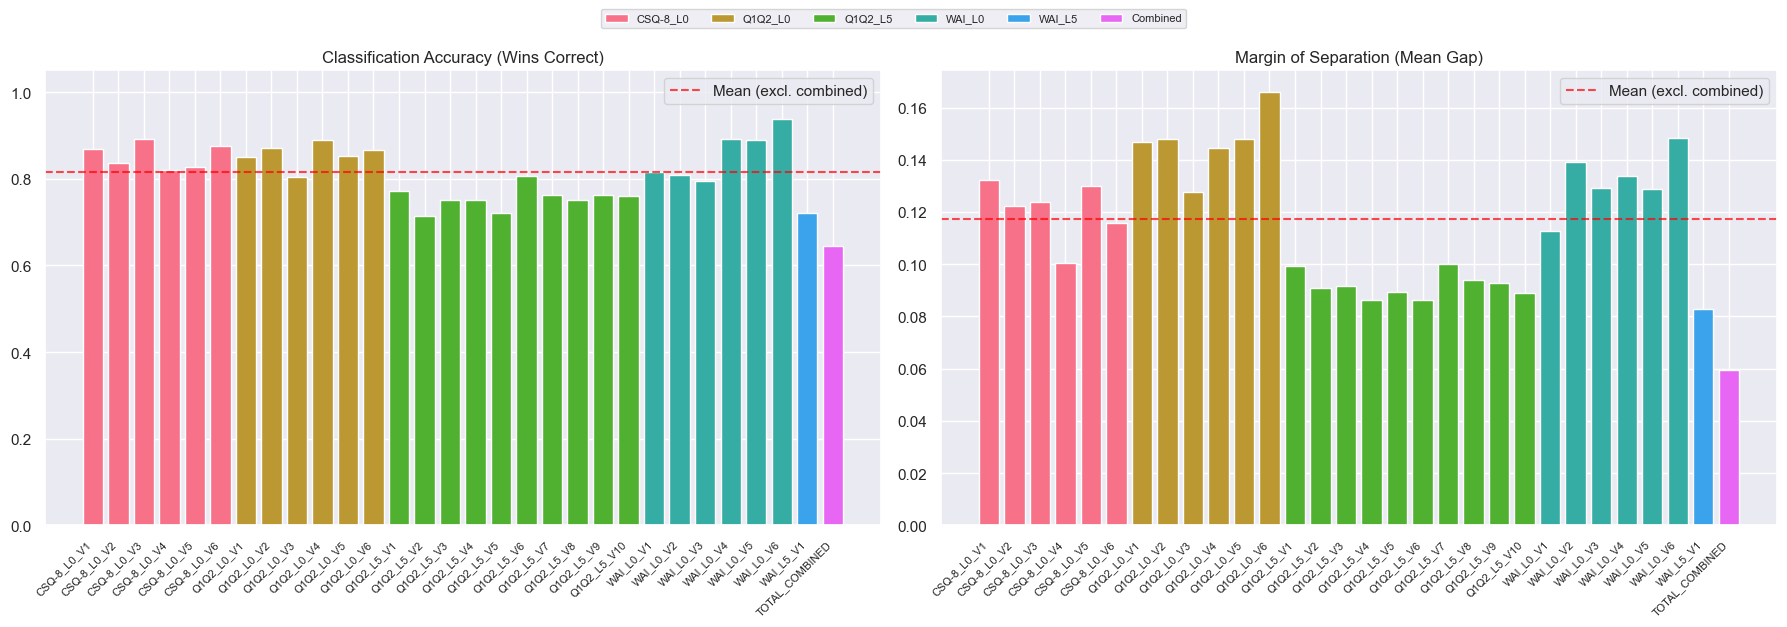

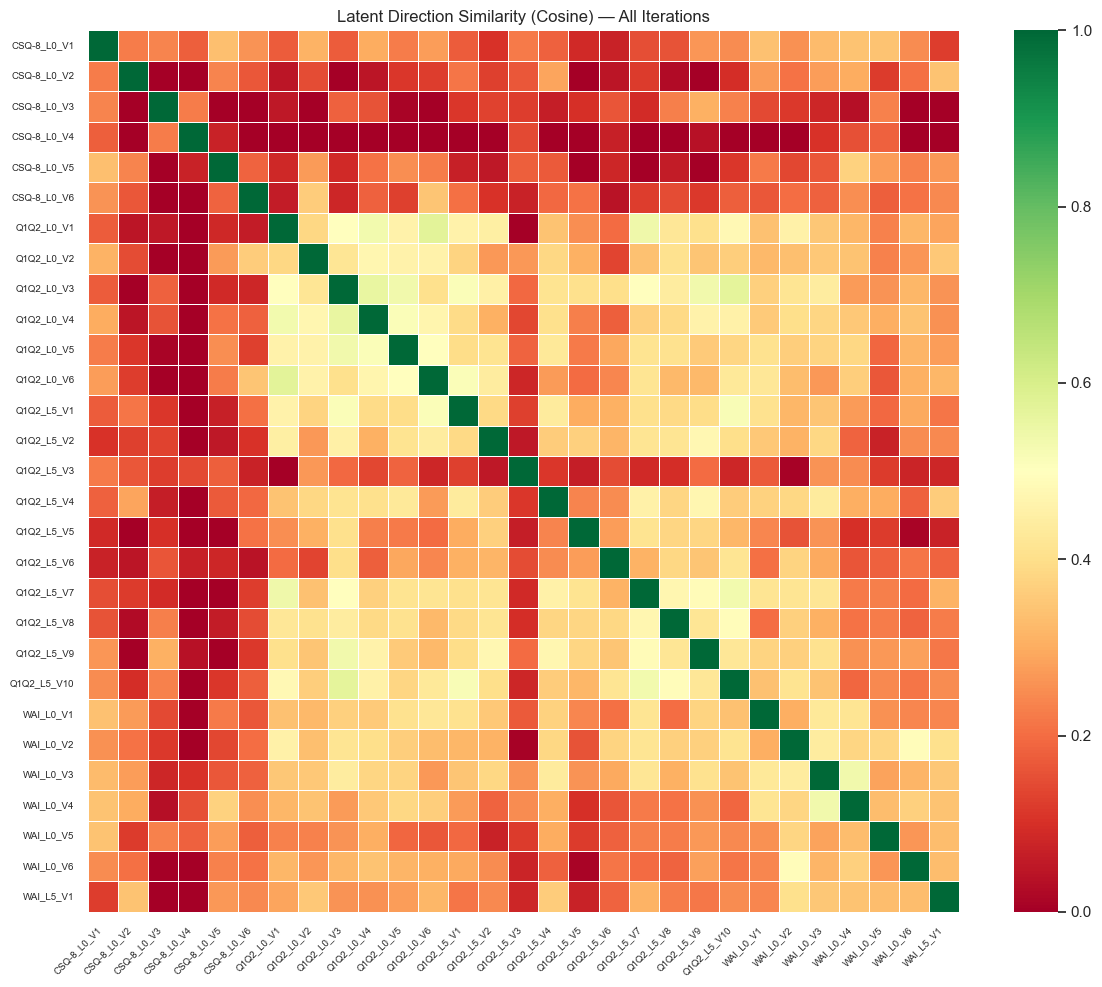

In [10]:
# --- Metrics comparison bar charts ---
comp_df = analyzer.get_comparison_df()

# Sort by experiment group, then iteration
comp_df["_sort"] = comp_df["Dataset"].apply(sort_key)
comp_df = comp_df.sort_values("_sort").drop(columns=["_sort"]).reset_index(drop=True)

# Color bars by experiment group
exp_groups = comp_df["Dataset"].apply(
    lambda x: "Combined" if x == "TOTAL_COMBINED" else "_".join(x.rsplit("_", 1)[:-1])
)
unique_exps = [e for e in exp_groups.unique() if e != "Combined"] + ["Combined"]
exp_palette = dict(zip(unique_exps, sns.color_palette("husl", len(unique_exps))))
bar_colors = [exp_palette[e] for e in exp_groups]

display(comp_df[["Dataset", "n_samples", "wins_correct", "mean_gap"]])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Wins Correct
axes[0].bar(range(len(comp_df)), comp_df["wins_correct"], color=bar_colors)
axes[0].set_xticks(range(len(comp_df)))
axes[0].set_xticklabels(comp_df["Dataset"], rotation=45, ha="right", fontsize=8)
axes[0].axhline(
    comp_df.loc[comp_df["Dataset"] != "TOTAL_COMBINED", "wins_correct"].mean(),
    color="red", linestyle="--", alpha=0.7, label="Mean (excl. combined)"
)
axes[0].set_title("Classification Accuracy (Wins Correct)")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Mean Gap
axes[1].bar(range(len(comp_df)), comp_df["mean_gap"], color=bar_colors)
axes[1].set_xticks(range(len(comp_df)))
axes[1].set_xticklabels(comp_df["Dataset"], rotation=45, ha="right", fontsize=8)
axes[1].axhline(
    comp_df.loc[comp_df["Dataset"] != "TOTAL_COMBINED", "mean_gap"].mean(),
    color="red", linestyle="--", alpha=0.7, label="Mean (excl. combined)"
)
axes[1].set_title("Margin of Separation (Mean Gap)")
axes[1].legend()

# Experiment group legend
legend_patches = [Patch(facecolor=exp_palette[e], label=e) for e in unique_exps]
fig.legend(handles=legend_patches, loc="upper center", ncol=len(unique_exps),
           bbox_to_anchor=(0.5, 1.05), fontsize=8)
plt.tight_layout()
plt.show()

# --- Full direction similarity heatmap ---
keys = sorted(
    [k for k in analyzer.directions if k != "TOTAL_COMBINED"],
    key=sort_key
)

mat = np.zeros((len(keys), len(keys)))
for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        mat[i, j] = np.dot(analyzer.directions[k1], analyzer.directions[k2])

sim_df = pd.DataFrame(mat, index=keys, columns=keys)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, annot=False, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
plt.title("Latent Direction Similarity (Cosine) \u2014 All Iterations")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 7. Per-Experiment Iteration Analysis

For each experiment group (Oracle + LookAhead), we examine how metrics and preference
directions evolve across DPO training iterations:
- **Bar charts**: Wins Correct and Mean Gap per iteration.
- **Heatmap**: Direction similarity between iterations within the same experiment.
  High diagonal similarity indicates stable learning; drift suggests the model is
  discovering different preference dimensions over time.


Experiment: CSQ-8_L0 (6 iterations)


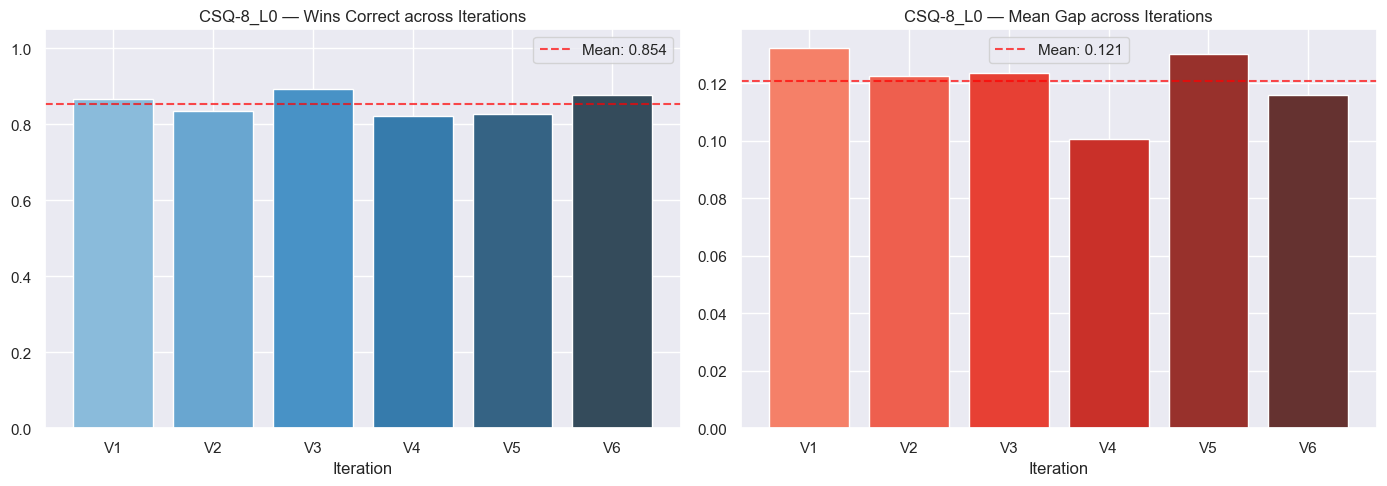

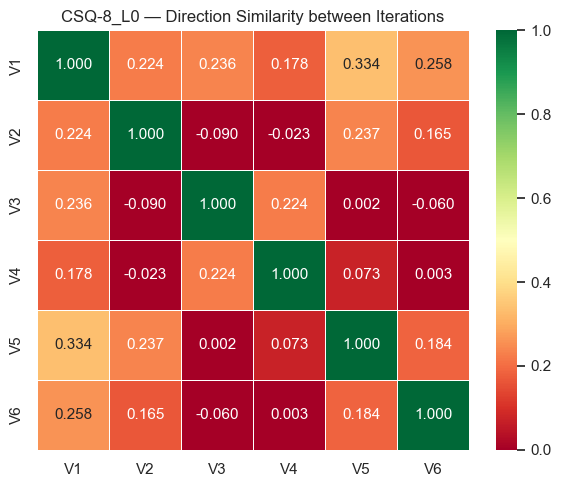


Experiment: Q1Q2_L0 (6 iterations)


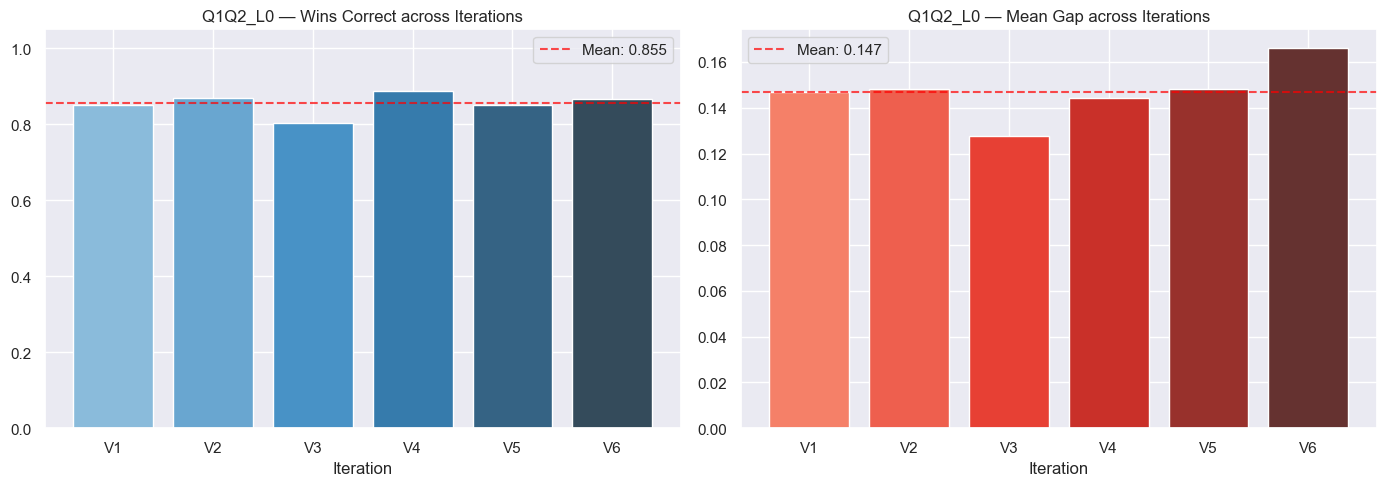

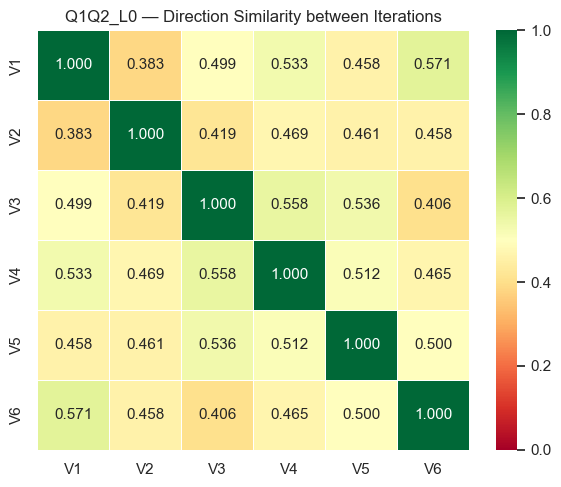


Experiment: Q1Q2_L5 (10 iterations)


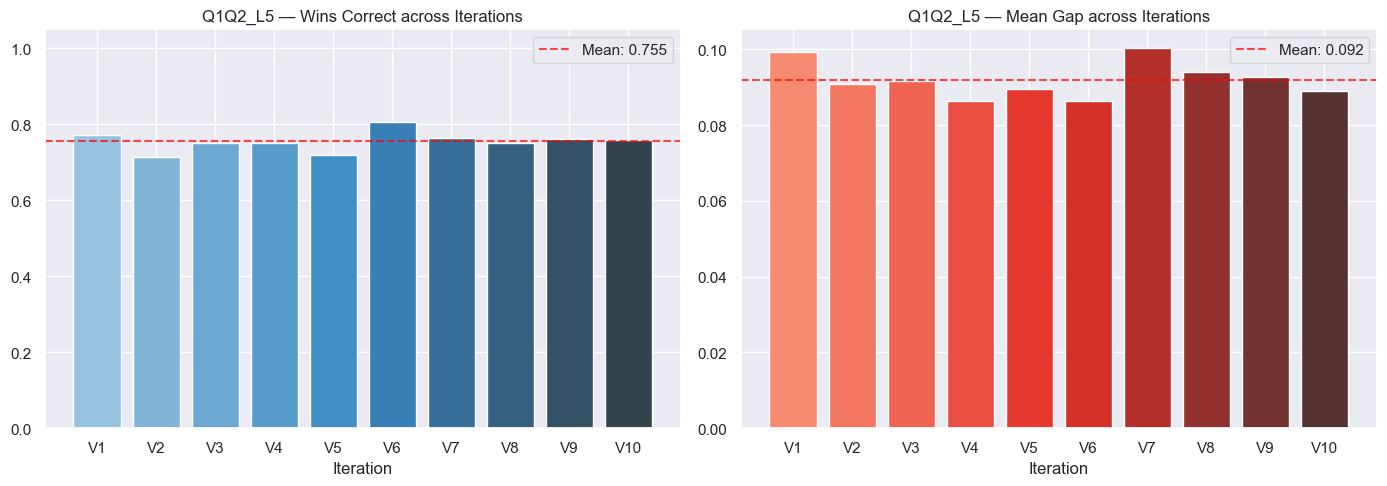

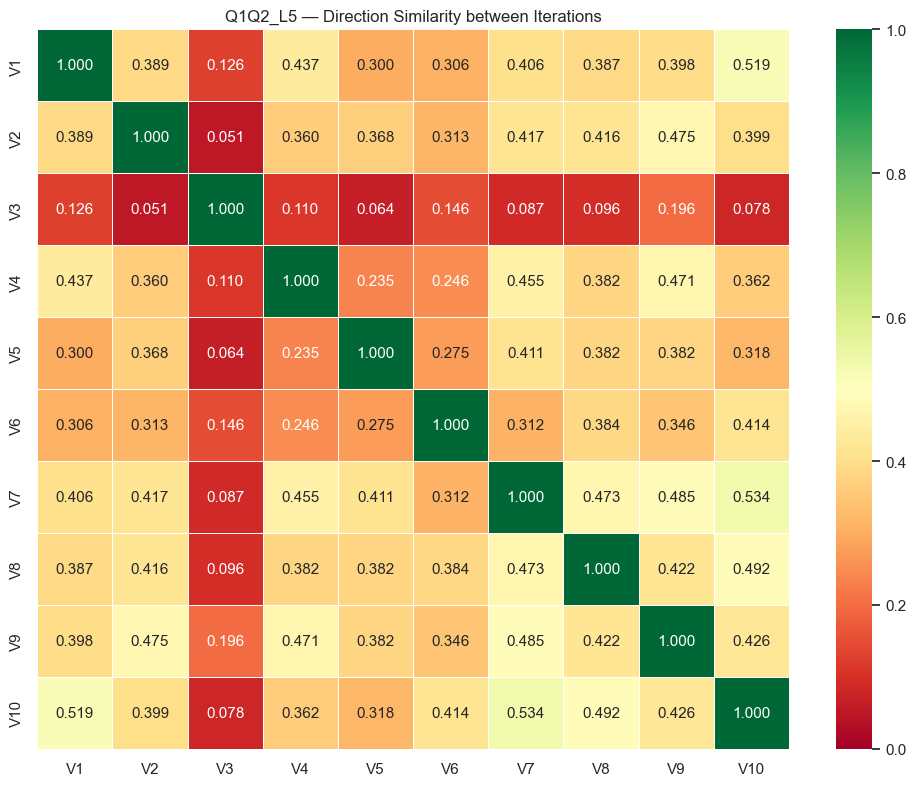


Experiment: WAI_L0 (6 iterations)


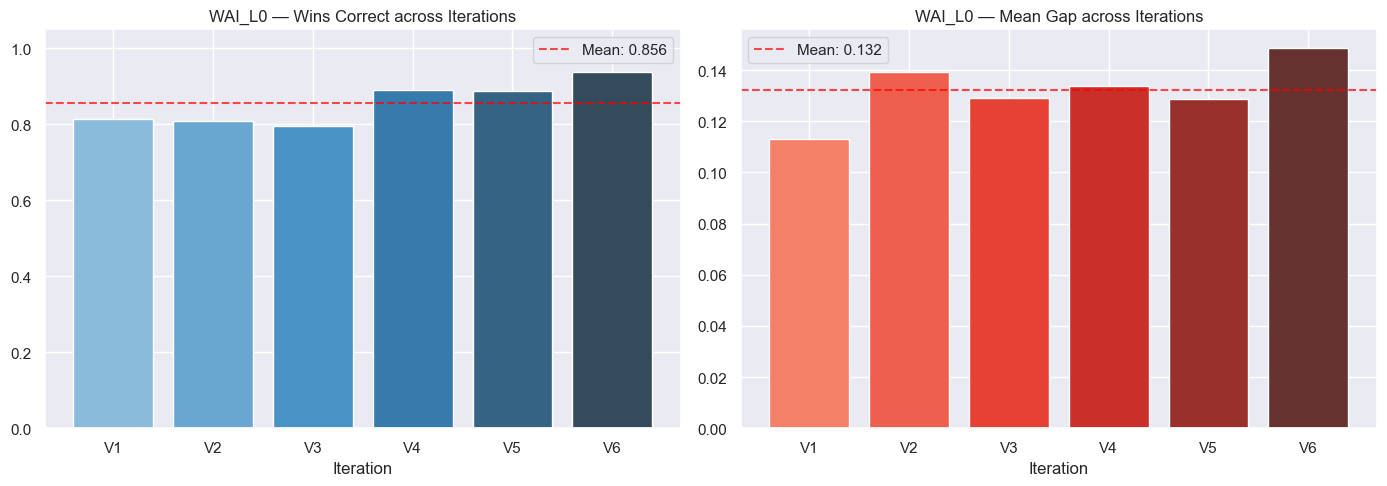

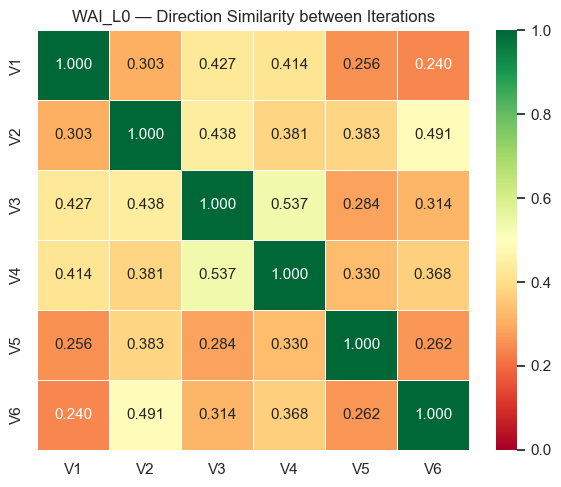

In [11]:
for exp, members in sorted(experiment_datasets.items()):
    if len(members) < 2:
        continue  # Skip experiments with only 1 iteration

    print(f"\n{'='*60}")
    print(f"Experiment: {exp} ({len(members)} iterations)")
    print(f"{'='*60}")

    iter_labels = [m.rsplit("_", 1)[-1] for m in members]

    # --- Metrics across iterations ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    accuracies = [analyzer.results[m]["wins_correct"] for m in members]
    gaps = [analyzer.results[m]["mean_gap"] for m in members]

    axes[0].bar(iter_labels, accuracies, color=sns.color_palette("Blues_d", len(members)))
    axes[0].axhline(np.mean(accuracies), color="red", linestyle="--", alpha=0.7,
                    label=f"Mean: {np.mean(accuracies):.3f}")
    axes[0].set_title(f"{exp} \u2014 Wins Correct across Iterations")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xlabel("Iteration")
    axes[0].legend()

    axes[1].bar(iter_labels, gaps, color=sns.color_palette("Reds_d", len(members)))
    axes[1].axhline(np.mean(gaps), color="red", linestyle="--", alpha=0.7,
                    label=f"Mean: {np.mean(gaps):.3f}")
    axes[1].set_title(f"{exp} \u2014 Mean Gap across Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Direction similarity heatmap within experiment ---
    mat = np.zeros((len(members), len(members)))
    for i, k1 in enumerate(members):
        for j, k2 in enumerate(members):
            mat[i, j] = np.dot(analyzer.directions[k1], analyzer.directions[k2])

    fig, ax = plt.subplots(figsize=(max(6, len(members)), max(5, len(members) * 0.8)))
    sns.heatmap(pd.DataFrame(mat, index=iter_labels, columns=iter_labels),
                annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{exp} \u2014 Direction Similarity between Iterations")
    plt.tight_layout()
    plt.show()

## 8. Twin-Lookahead Comparison

Compares L0 (greedy, no lookahead) vs L5 (5-step lookahead) for the same oracle.
This reveals whether planning depth changes what the model learns to prefer:
- **Aggregated metrics**: Mean accuracy and gap across iterations for each lookahead.
- **Cross-iteration heatmap**: Shows whether L0 and L5 directions are similar or divergent.
- **Combined direction cosine**: Single number summarizing L0/L5 alignment.


Twin-Lookahead: Q1Q2 (L0: 6 iters, L5: 10 iters)


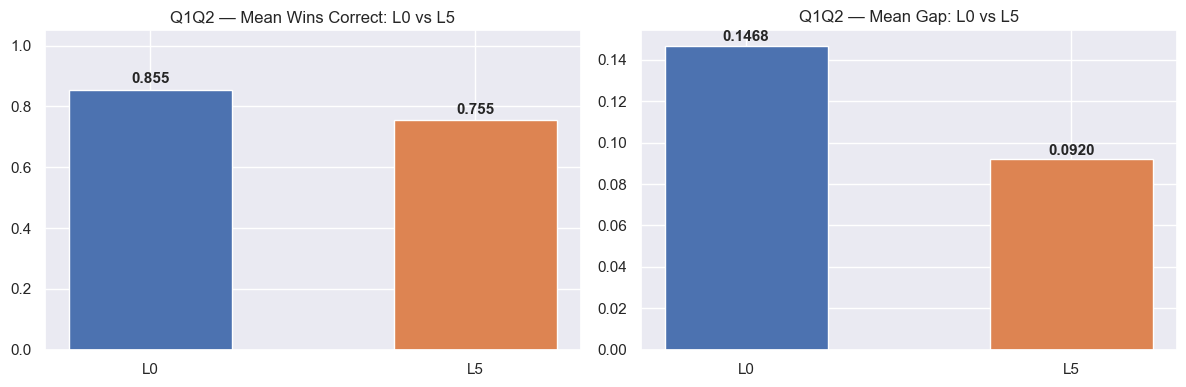

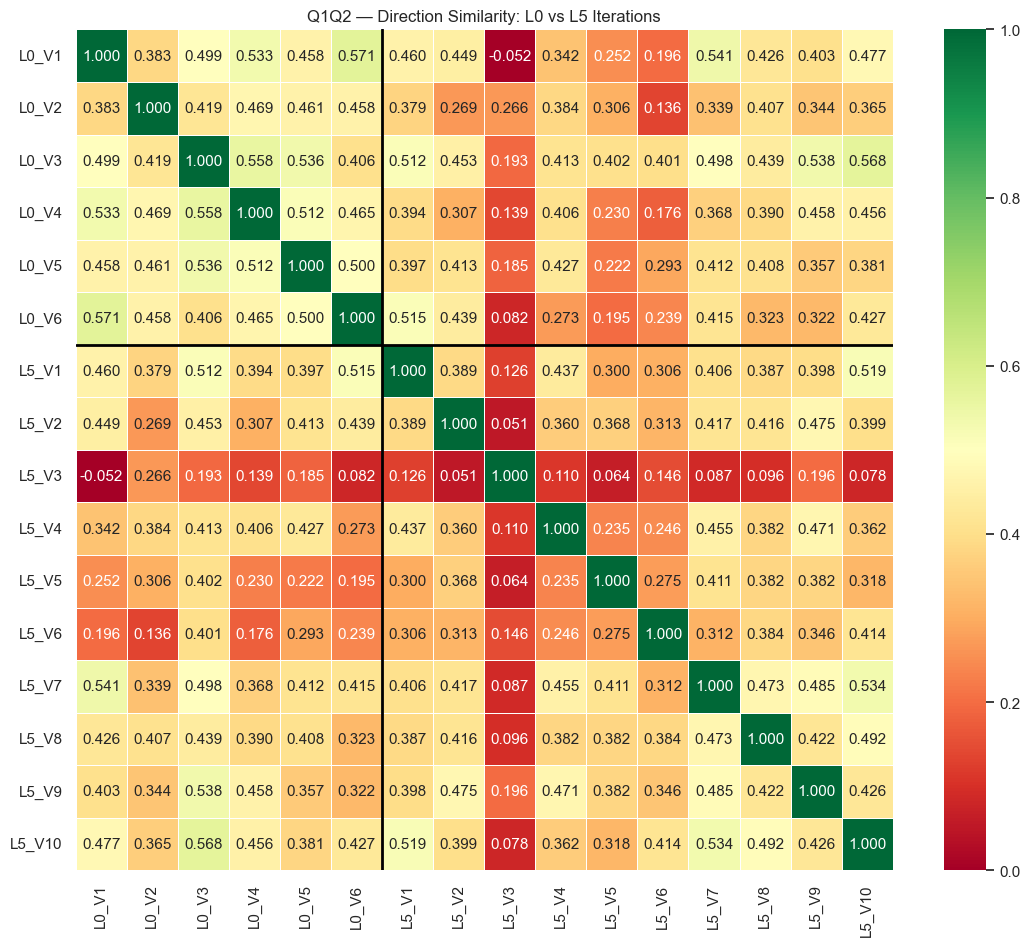

  Combined direction similarity (L0 vs L5): 0.7386

CSQ-8: Skipping — missing L0 or L5 data

Twin-Lookahead: WAI (L0: 6 iters, L5: 1 iters)


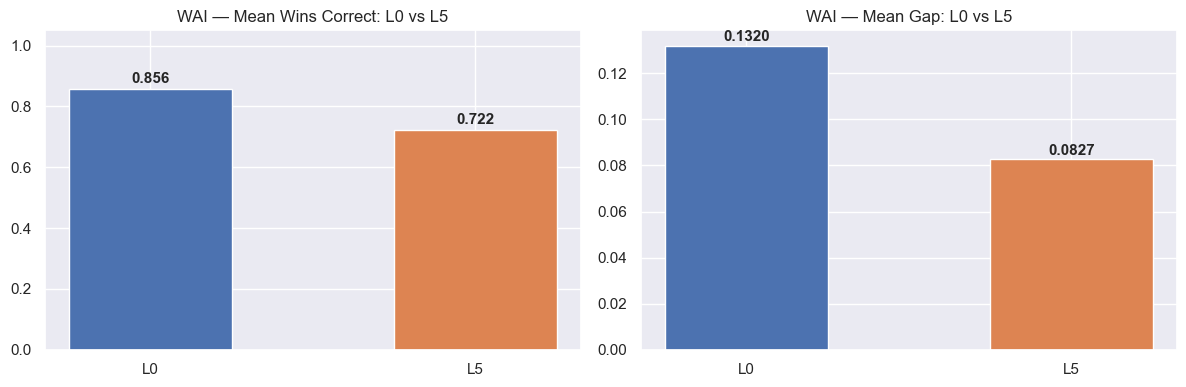

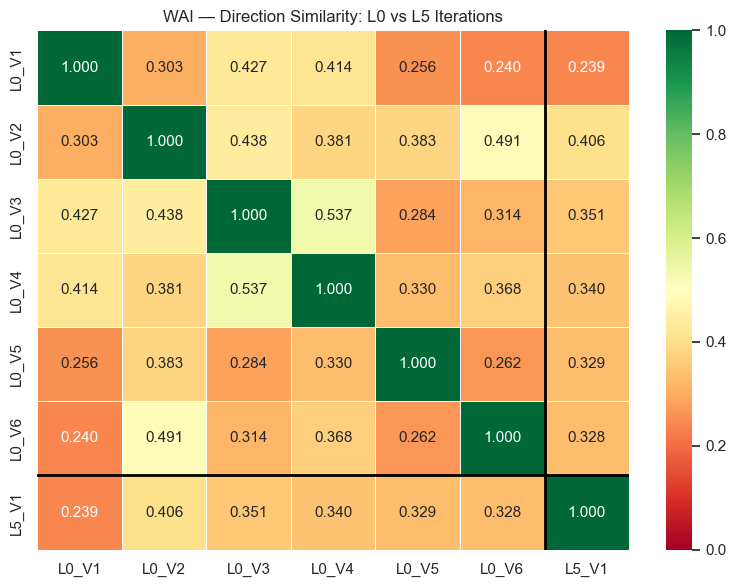

  Combined direction similarity (L0 vs L5): 0.4855


In [12]:
for oracle in Config.ORACLES:
    l0_members = experiment_datasets.get(f"{oracle}_L0", [])
    l5_members = experiment_datasets.get(f"{oracle}_L5", [])

    if not l0_members or not l5_members:
        print(f"\n{oracle}: Skipping \u2014 missing L0 or L5 data")
        continue

    print(f"\n{'='*60}")
    print(f"Twin-Lookahead: {oracle} (L0: {len(l0_members)} iters, L5: {len(l5_members)} iters)")
    print(f"{'='*60}")

    # --- Aggregated metrics: L0 vs L5 ---
    l0_acc = np.mean([analyzer.results[m]["wins_correct"] for m in l0_members])
    l5_acc = np.mean([analyzer.results[m]["wins_correct"] for m in l5_members])
    l0_gap = np.mean([analyzer.results[m]["mean_gap"] for m in l0_members])
    l5_gap = np.mean([analyzer.results[m]["mean_gap"] for m in l5_members])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(["L0", "L5"], [l0_acc, l5_acc], color=["#4c72b0", "#dd8452"], width=0.5)
    axes[0].set_title(f"{oracle} \u2014 Mean Wins Correct: L0 vs L5")
    axes[0].set_ylim(0, 1.05)
    for j, v in enumerate([l0_acc, l5_acc]):
        axes[0].text(j, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

    axes[1].bar(["L0", "L5"], [l0_gap, l5_gap], color=["#4c72b0", "#dd8452"], width=0.5)
    axes[1].set_title(f"{oracle} \u2014 Mean Gap: L0 vs L5")
    for j, v in enumerate([l0_gap, l5_gap]):
        axes[1].text(j, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

    # --- Cross-iteration direction similarity heatmap ---
    all_members = l0_members + l5_members
    l0_labels = [f"L0_{m.rsplit('_', 1)[-1]}" for m in l0_members]
    l5_labels = [f"L5_{m.rsplit('_', 1)[-1]}" for m in l5_members]
    combined_labels = l0_labels + l5_labels

    mat = np.zeros((len(all_members), len(all_members)))
    for i, k1 in enumerate(all_members):
        for j, k2 in enumerate(all_members):
            mat[i, j] = np.dot(analyzer.directions[k1], analyzer.directions[k2])

    fig, ax = plt.subplots(figsize=(max(8, len(all_members) * 0.7),
                                    max(6, len(all_members) * 0.6)))
    sns.heatmap(pd.DataFrame(mat, index=combined_labels, columns=combined_labels),
                annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{oracle} \u2014 Direction Similarity: L0 vs L5 Iterations")
    # Separator line between L0 and L5 blocks
    ax.axhline(len(l0_members), color="black", linewidth=2)
    ax.axvline(len(l0_members), color="black", linewidth=2)
    plt.tight_layout()
    plt.show()

    # --- Combined direction cosine ---
    l0_dir = np.mean([analyzer.directions[m] for m in l0_members], axis=0)
    l0_dir /= np.linalg.norm(l0_dir) + 1e-12
    l5_dir = np.mean([analyzer.directions[m] for m in l5_members], axis=0)
    l5_dir /= np.linalg.norm(l5_dir) + 1e-12
    cos_sim = np.dot(l0_dir, l5_dir)
    print(f"  Combined direction similarity (L0 vs L5): {cos_sim:.4f}")

## 9. Twin-Oracle Comparison

Compares oracles (Q1Q2, CSQ-8, WAI) holding lookahead constant.
This reveals whether different evaluation metrics lead to different notions of "preferred":
- **Aggregated metrics**: Mean accuracy and gap per oracle.
- **Combined direction similarity**: Do oracle-averaged directions agree?
- **Full iteration heatmap**: Pairwise similarity across all oracle/iteration combinations.


Twin-Oracle: L0 (Q1Q2, CSQ-8, WAI)


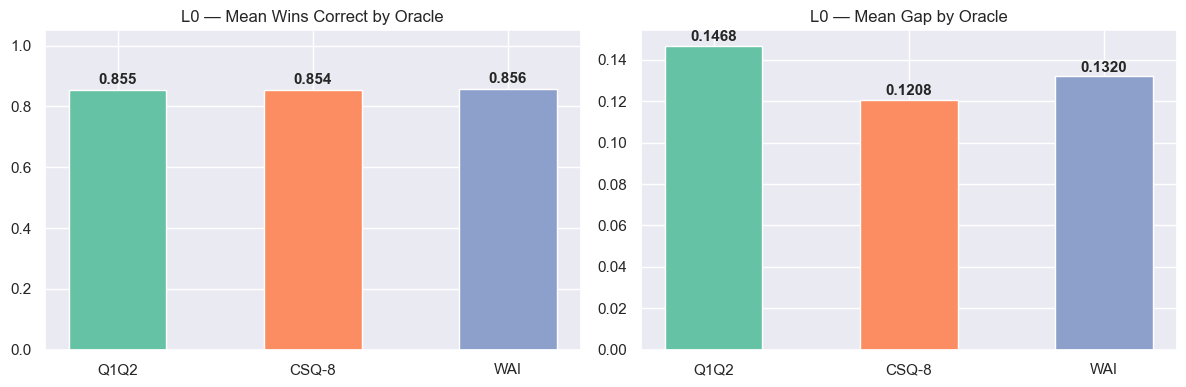

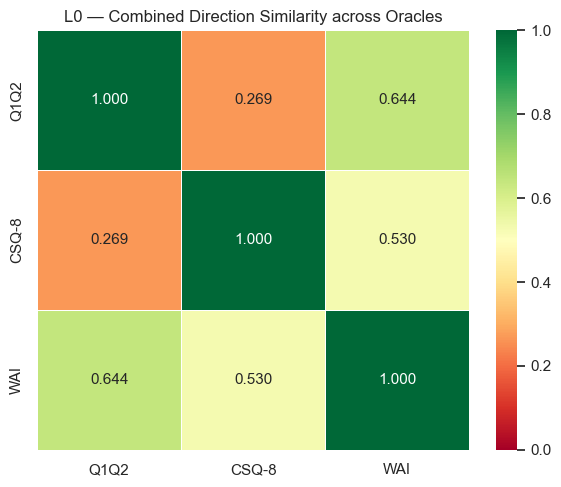

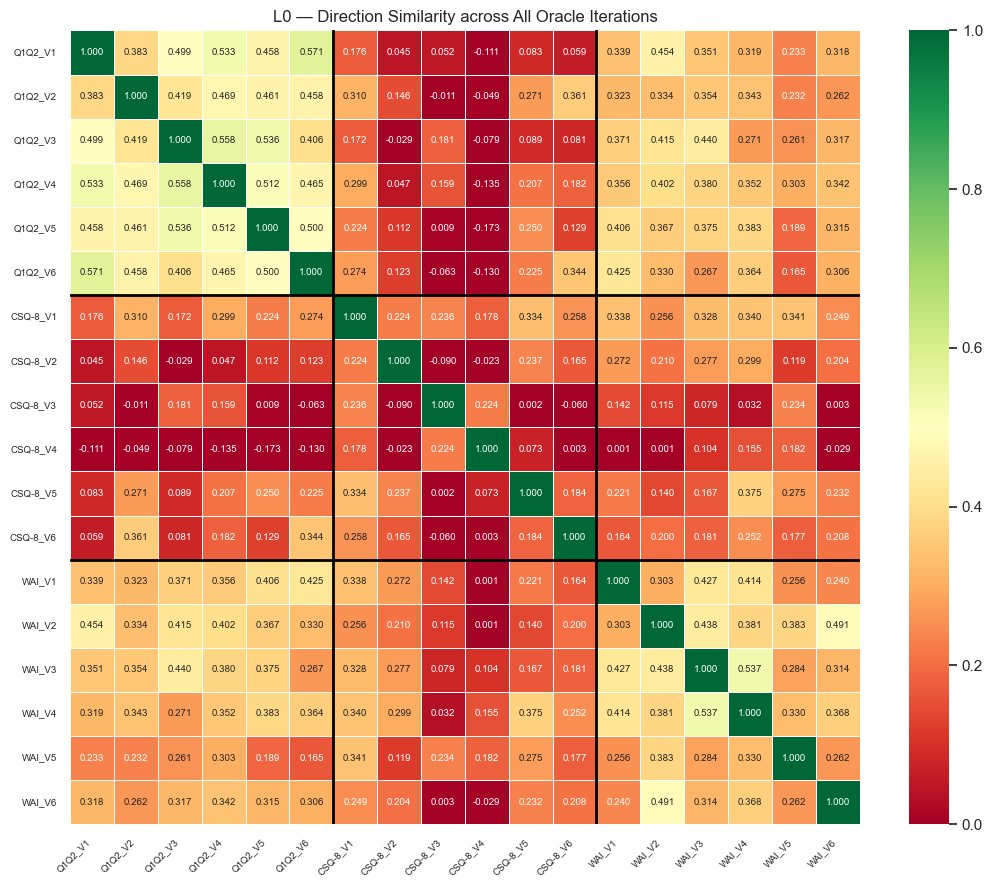


Twin-Oracle: L5 (Q1Q2, WAI)


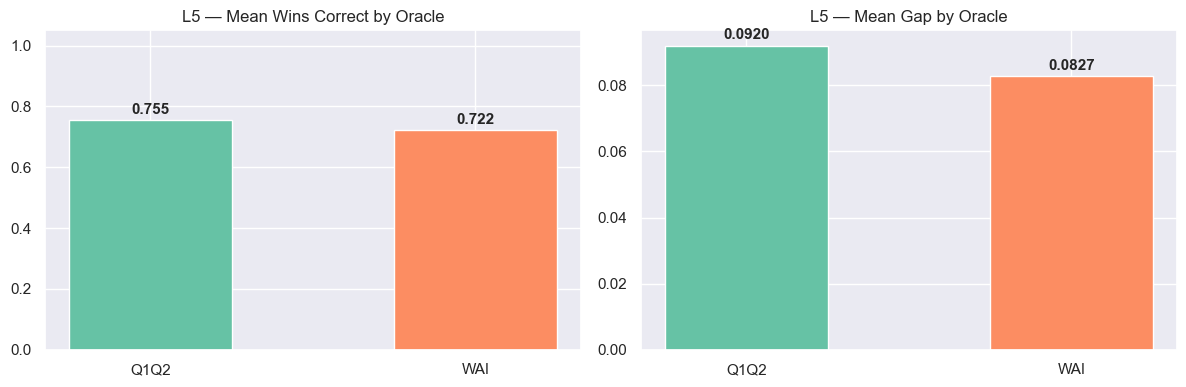

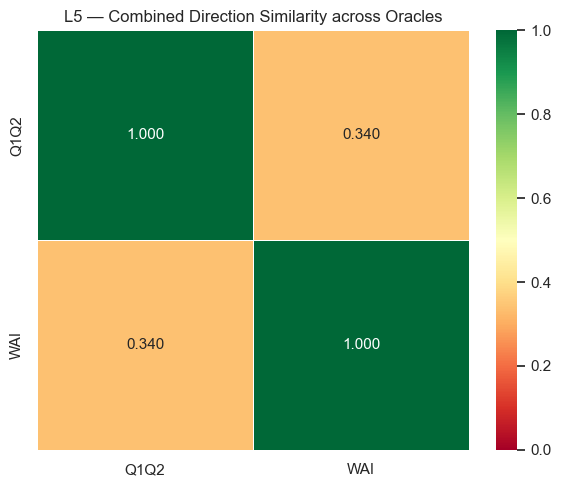

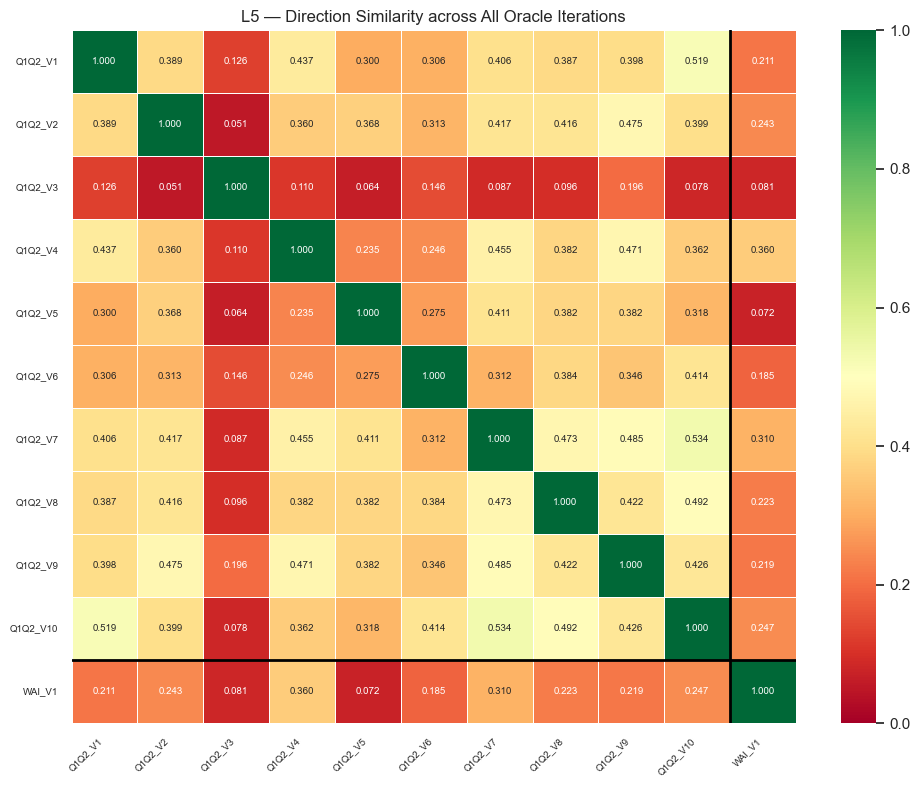

In [13]:
for lookahead in ["L0", "L5"]:
    oracle_groups = {}
    for oracle in Config.ORACLES:
        exp = f"{oracle}_{lookahead}"
        if exp in experiment_datasets and experiment_datasets[exp]:
            oracle_groups[oracle] = experiment_datasets[exp]

    if len(oracle_groups) < 2:
        print(f"\n{lookahead}: Skipping \u2014 fewer than 2 oracles available")
        continue

    print(f"\n{'='*60}")
    print(f"Twin-Oracle: {lookahead} ({', '.join(oracle_groups.keys())})")
    print(f"{'='*60}")

    oracles_present = list(oracle_groups.keys())
    oracle_colors = dict(zip(oracles_present, sns.color_palette("Set2", len(oracles_present))))

    # --- Aggregated metrics per oracle ---
    mean_accs = [np.mean([analyzer.results[m]["wins_correct"] for m in oracle_groups[o]])
                 for o in oracles_present]
    mean_gaps = [np.mean([analyzer.results[m]["mean_gap"] for m in oracle_groups[o]])
                 for o in oracles_present]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(oracles_present, mean_accs,
                color=[oracle_colors[o] for o in oracles_present], width=0.5)
    axes[0].set_title(f"{lookahead} \u2014 Mean Wins Correct by Oracle")
    axes[0].set_ylim(0, 1.05)
    for j, v in enumerate(mean_accs):
        axes[0].text(j, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

    axes[1].bar(oracles_present, mean_gaps,
                color=[oracle_colors[o] for o in oracles_present], width=0.5)
    axes[1].set_title(f"{lookahead} \u2014 Mean Gap by Oracle")
    for j, v in enumerate(mean_gaps):
        axes[1].text(j, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

    # --- Combined direction similarity across oracles ---
    combined_dirs = {}
    for oracle in oracles_present:
        members = oracle_groups[oracle]
        d = np.mean([analyzer.directions[m] for m in members], axis=0)
        d /= np.linalg.norm(d) + 1e-12
        combined_dirs[oracle] = d

    mat = np.zeros((len(oracles_present), len(oracles_present)))
    for i, o1 in enumerate(oracles_present):
        for j, o2 in enumerate(oracles_present):
            mat[i, j] = np.dot(combined_dirs[o1], combined_dirs[o2])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(pd.DataFrame(mat, index=oracles_present, columns=oracles_present),
                annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{lookahead} \u2014 Combined Direction Similarity across Oracles")
    plt.tight_layout()
    plt.show()

    # --- Full cross-oracle iteration heatmap ---
    all_members = []
    all_labels = []
    group_sizes = []
    for oracle in oracles_present:
        members = oracle_groups[oracle]
        all_members.extend(members)
        all_labels.extend([f"{oracle}_{m.rsplit('_', 1)[-1]}" for m in members])
        group_sizes.append(len(members))

    mat = np.zeros((len(all_members), len(all_members)))
    for i, k1 in enumerate(all_members):
        for j, k2 in enumerate(all_members):
            mat[i, j] = np.dot(analyzer.directions[k1], analyzer.directions[k2])

    fig, ax = plt.subplots(figsize=(max(10, len(all_members) * 0.6),
                                    max(8, len(all_members) * 0.5)))
    sns.heatmap(pd.DataFrame(mat, index=all_labels, columns=all_labels),
                annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={"fontsize": 7})
    ax.set_title(f"{lookahead} \u2014 Direction Similarity across All Oracle Iterations")
    # Separator lines between oracle groups
    cumsum = 0
    for size in group_sizes[:-1]:
        cumsum += size
        ax.axhline(cumsum, color="black", linewidth=2)
        ax.axvline(cumsum, color="black", linewidth=2)
    plt.xticks(fontsize=7, rotation=45, ha="right")
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

---
# Semantic Interpretation (Sections 10–14)

Having established what the preference directions look like geometrically, we now
interpret them semantically. We project a large vocabulary onto each direction to
discover *what concepts* the model associates with winning vs losing responses.

## 10. Word Ranking Analysis

Projects ~50k English words onto each preference direction. For each word, its
**projection score** indicates how aligned it is with the "preferred" direction:
- **Positive scores**: Concepts the model associates with winning responses.
- **Negative scores**: Concepts the model associates with losing responses.

We show:
1. **Global top/bottom words** (averaged across all datasets).
2. **Per-dataset top/bottom words** for detailed comparison.
3. **Consistency scatter**: Top words plotted by mean score vs standard deviation —
   low std means all datasets agree this concept is preferred.

In [14]:
print("\n--- Running Word Projection Analysis ---")

# 1. Prepare vocabulary: common English words, 3+ chars, alphabetic only
cand_words = sorted({w.lower() for w in top_n_list("en", Config.VOCAB_SIZE)
                     if re.match(r"^[a-z]{3,}$", w.lower())})
print(f"Vocabulary Size: {len(cand_words)}")

# 2. Cache word embeddings to avoid recomputation
os.makedirs(Config.CACHE_DIR, exist_ok=True)
vocab_hash = hashlib.md5("".join(cand_words).encode()).hexdigest()[:8]
cache_file = Path(Config.CACHE_DIR) / f"words_{vocab_hash}_{Config.MODEL_NAME.replace('/', '_')}.npy"

if cache_file.exists():
    print(f"Loading cached word embeddings from {cache_file}")
    word_embs = np.load(cache_file)
else:
    print("Computing word embeddings (this may take a moment)...")
    word_embs = engine.encode(cand_words, batch_size=256, verbose=True)
    np.save(cache_file, word_embs)

# 3. Project every word onto every preference direction
word_scores = pd.DataFrame({"word": cand_words})
for name, direction in analyzer.directions.items():
    word_scores[name] = word_embs @ direction

# 4. Aggregate stats across all directions
score_cols = list(analyzer.directions.keys())
word_scores["mean_score"] = word_scores[score_cols].mean(axis=1)
word_scores["std_score"] = word_scores[score_cols].std(axis=1)
word_scores_sorted = word_scores.sort_values("mean_score", ascending=False)

# Lookup table: word -> row index (used by later sections)
word_to_idx = {w: i for i, w in enumerate(word_scores["word"].tolist())}


--- Running Word Projection Analysis ---
Vocabulary Size: 47361
Loading cached word embeddings from emb_cache_words\words_0ba65b02_Alibaba-NLP_gte-base-en-v1.5.npy


In [15]:
# --- Global top/bottom concepts ---
print("\n=== Top Concepts: Positive vs Negative ===")
top_pos = word_scores_sorted[["word", "mean_score", "std_score"]].head(15).copy()
top_pos.insert(0, "rank", range(1, len(top_pos) + 1))

top_neg = word_scores[["word", "mean_score", "std_score"]].nsmallest(15, "mean_score").copy()
top_neg.insert(0, "rank", range(1, len(top_neg) + 1))

styled_pos = style_table(top_pos, score_col="mean_score", cmap="Greens")
styled_neg = style_table(top_neg, score_col="mean_score", cmap="Reds_r")

display(HTML(f"""
<div style="display: flex; gap: 20px;">
    <div style="flex: 1;">
        <h4>Top Positive Concepts (What the model likes)</h4>
        {styled_pos.to_html()}
    </div>
    <div style="flex: 1;">
        <h4>Top Negative Concepts (What the model dislikes)</h4>
        {styled_neg.to_html()}
    </div>
</div>
"""))


=== Top Concepts: Positive vs Negative ===


rank,word,mean_score,std_score
1,motivating,0.1657,0.0779
2,motivator,0.1608,0.0775
3,motivates,0.1583,0.0774
4,motivate,0.1572,0.0759
5,motivation,0.1570,0.0849
6,motivational,0.1477,0.0781
7,dieting,0.1453,0.0979
8,motivated,0.1352,0.0651
9,fitness,0.1311,0.0807
10,inspirations,0.1268,0.0751


In [16]:
# --- Per-dataset top/bottom concepts ---
for name in score_cols:
    print(f"\n--- Top Concepts for {name}: Positive vs Negative ---")
    df_pos = word_scores[["word", name]].nlargest(15, name).copy()
    df_pos.insert(0, "rank", range(1, len(df_pos) + 1))

    df_neg = word_scores[["word", name]].nsmallest(15, name).copy()
    df_neg.insert(0, "rank", range(1, len(df_neg) + 1))

    styled_pos_ds = style_table(df_pos[["rank", "word", name]], score_col=name, cmap="Greens")
    styled_neg_ds = style_table(df_neg[["rank", "word", name]], score_col=name, cmap="Reds_r")

    display(HTML(f"""
    <div style="display: flex; gap: 20px;">
        <div style="flex: 1;">
            <h5>Positive Concepts</h5>
            {styled_pos_ds.to_html()}
        </div>
        <div style="flex: 1;">
            <h5>Negative Concepts</h5>
            {styled_neg_ds.to_html()}
        </div>
    </div>
    """))


--- Top Concepts for Q1Q2_L0_V1: Positive vs Negative ---


rank,word,Q1Q2_L0_V1
1,addictions,0.2813
2,motivating,0.2645
3,motivation,0.2599
4,motivates,0.2596
5,motivations,0.2568
6,motivator,0.2513
7,abstaining,0.2407
8,motivated,0.2388
9,addiction,0.2381
10,inspirations,0.2361



--- Top Concepts for Q1Q2_L0_V2: Positive vs Negative ---


rank,word,Q1Q2_L0_V2
1,interviewee,0.2305
2,counseling,0.2186
3,facilitating,0.2118
4,wellbeing,0.2098
5,counselling,0.2080
6,corresponded,0.2063
7,interview,0.2039
8,interviewing,0.2017
9,fitness,0.1983
10,interviewer,0.1982



--- Top Concepts for Q1Q2_L0_V3: Positive vs Negative ---


...

rank,word,WAI_L0_V6
1,facilitator,0.2358
2,initiator,0.2196
3,meet,0.2127
4,introductions,0.2071
5,initiate,0.1949
6,facilitation,0.1947
7,facilitators,0.1903
8,initiates,0.1888
9,collaborating,0.1873
10,initiating,0.1815



--- Top Concepts for WAI_L5_V1: Positive vs Negative ---


rank,word,WAI_L5_V1
1,facilitator,0.2033
2,facilitation,0.1778
3,facilitators,0.1666
4,workable,0.1502
5,practicable,0.1461
6,proposing,0.1402
7,cooperate,0.1323
8,facilitate,0.1181
9,rehabilitating,0.1179
10,counseling,0.1176



--- Top Concepts for TOTAL_COMBINED: Positive vs Negative ---


rank,word,TOTAL_COMBINED
1,motivating,0.3030
2,motivator,0.2929
3,motivation,0.2911
4,motivates,0.2900
5,motivate,0.2878
6,dieting,0.2790
7,motivational,0.2736
8,fitness,0.2469
9,motivated,0.2436
10,mindset,0.2357


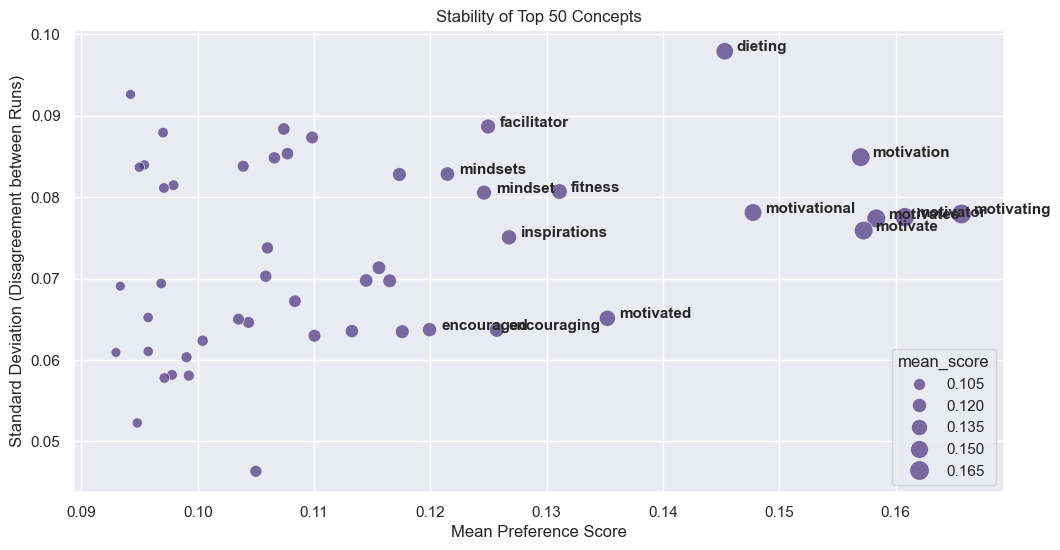

In [17]:
# --- Consistency scatter: mean score vs standard deviation for top 50 words ---
# Words in the upper-left are both highly preferred AND consistent across datasets.
plt.figure(figsize=(12, 6))
top_words = word_scores_sorted.head(50)
sns.scatterplot(data=top_words, x="mean_score", y="std_score",
                size="mean_score", sizes=(50, 200), alpha=0.7)

for i in range(15):
    row = top_words.iloc[i]
    plt.text(row["mean_score"] + 0.001, row["std_score"], row["word"],
             fontsize=11, fontweight="bold")

plt.title("Stability of Top 50 Concepts")
plt.xlabel("Mean Preference Score")
plt.ylabel("Standard Deviation (Disagreement between Runs)")
plt.show()

## 11. Oracle Fingerprint & POS Fingerprint

For each oracle (Q1Q2, CSQ-8, WAI), we average word projection scores across all its
datasets to get a single "fingerprint" score vector. This section answers:

1. **Spearman correlation**: Do oracles rank words similarly? High correlation means
   they value similar concepts; low correlation means they have distinct preferences.
2. **Pairwise scatter**: Visualize agreement/disagreement for top 1000 words.
   Outliers far from the diagonal are oracle-specific concepts.
3. **POS Fingerprint**: Part-of-speech distribution of each oracle's top-ranked words.
   Reveals whether oracles preferentially surface verbs (actions), nouns (concepts),
   adjectives (qualities), or adverbs (manner).

In [18]:
# --- Oracle-averaged word scores ---
oracle_avg_scores = {}
for oracle in Config.ORACLES:
    oracle_cols = [col for col in word_scores.columns
                   if col not in ("word", "mean_score", "std_score", "TOTAL_COMBINED")
                   and col.startswith(oracle)]
    if oracle_cols:
        oracle_avg_scores[oracle] = word_scores[oracle_cols].mean(axis=1).values
        print(f"{oracle}: averaged over {len(oracle_cols)} datasets")

oracle_names = list(oracle_avg_scores.keys())
n_oracles = len(oracle_names)

Q1Q2: averaged over 16 datasets
CSQ-8: averaged over 6 datasets
WAI: averaged over 7 datasets


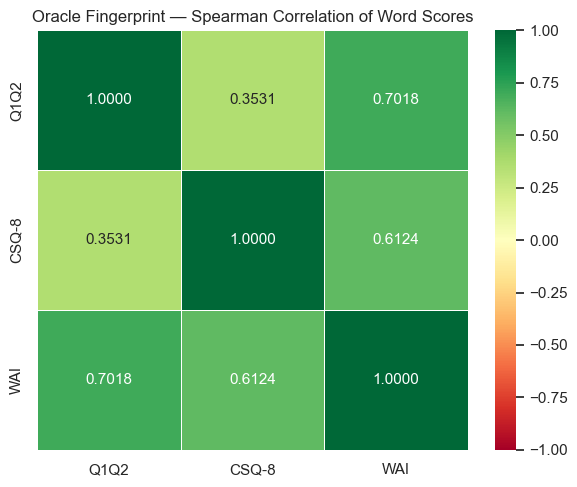


P-values:


,Q1Q2,CSQ-8,WAI
Q1Q2,0.00e+00,0.00e+00,0.00e+00
CSQ-8,0.00e+00,0.00e+00,0.00e+00
WAI,0.00e+00,0.00e+00,0.00e+00


In [19]:
# --- Spearman correlation matrix ---
corr_matrix = np.zeros((n_oracles, n_oracles))
pval_matrix = np.zeros((n_oracles, n_oracles))
for i, o1 in enumerate(oracle_names):
    for j, o2 in enumerate(oracle_names):
        rho, pval = spearmanr(oracle_avg_scores[o1], oracle_avg_scores[o2])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

corr_df = pd.DataFrame(corr_matrix, index=oracle_names, columns=oracle_names)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt=".4f", cmap="RdYlGn", vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Oracle Fingerprint \u2014 Spearman Correlation of Word Scores")
plt.tight_layout()
plt.show()

print("\nP-values:")
display(pd.DataFrame(pval_matrix, index=oracle_names, columns=oracle_names)
        .map(lambda x: f"{x:.2e}"))

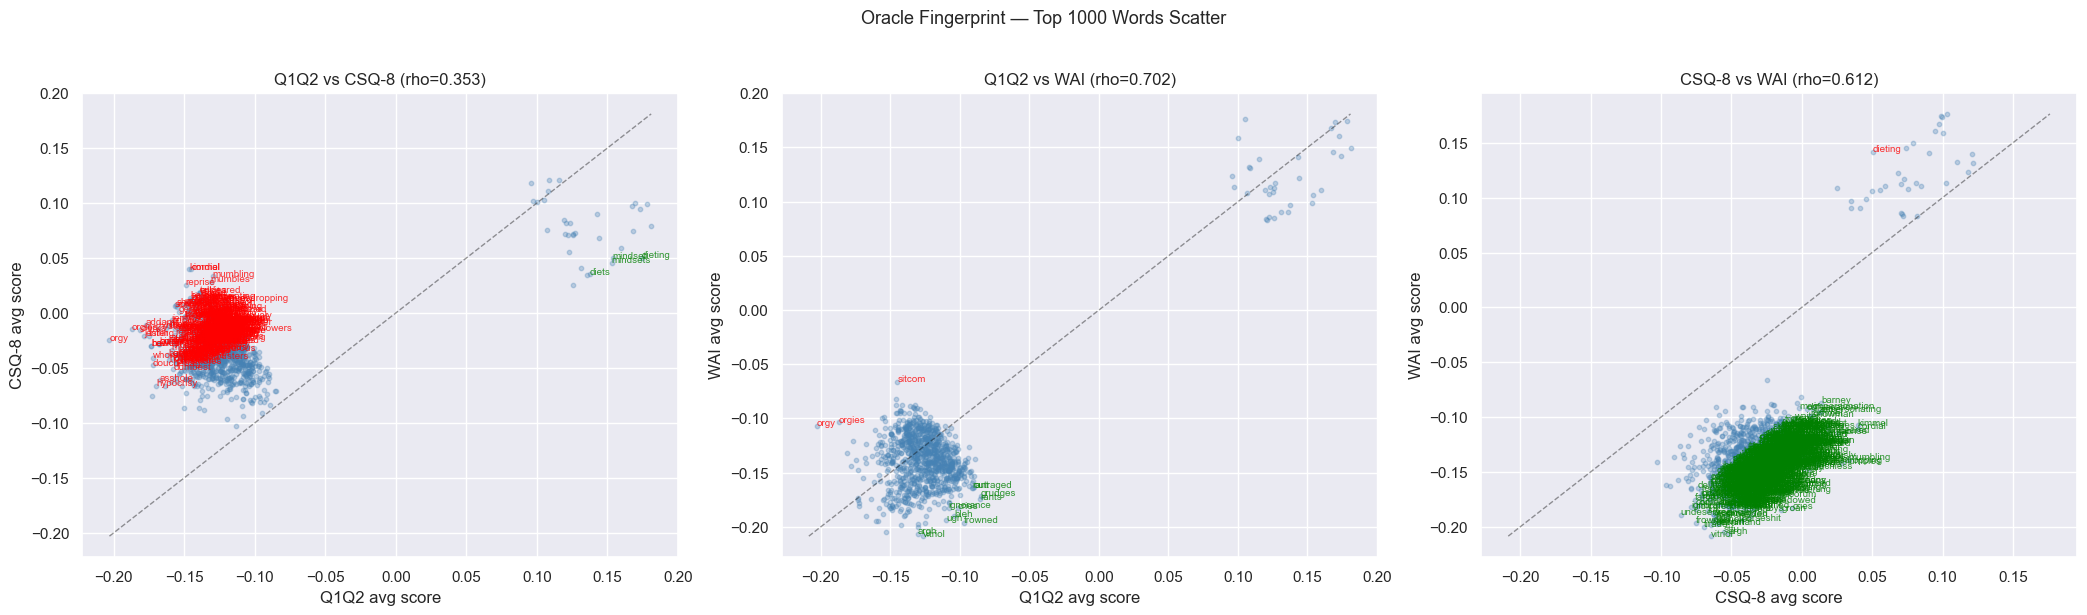

In [20]:
# --- Pairwise scatter plots for top 1000 words ---
# Words far from the diagonal are concepts that one oracle values much more than another.
top_k = 1000
top_idx = word_scores["mean_score"].abs().nlargest(top_k).index

pairs = list(combinations(oracle_names, 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 6))
if len(pairs) == 1:
    axes = [axes]

for ax, (o1, o2) in zip(axes, pairs):
    x = oracle_avg_scores[o1][top_idx]
    y = oracle_avg_scores[o2][top_idx]

    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")

    # Diagonal reference line
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", alpha=0.4, linewidth=1)

    # Highlight outliers (residual > 2.5 std from diagonal)
    residuals = y - x
    threshold = 2.5 * residuals.std()

    for idx_val in top_idx:
        r = oracle_avg_scores[o2][idx_val] - oracle_avg_scores[o1][idx_val]
        if abs(r) > threshold:
            word = word_scores.loc[idx_val, "word"]
            ax.annotate(word,
                       (oracle_avg_scores[o1][idx_val], oracle_avg_scores[o2][idx_val]),
                       fontsize=7, alpha=0.8,
                       color="red" if r > 0 else "green")

    rho = corr_df.loc[o1, o2]
    ax.set_xlabel(f"{o1} avg score")
    ax.set_ylabel(f"{o2} avg score")
    ax.set_title(f"{o1} vs {o2} (rho={rho:.3f})")

plt.suptitle("Oracle Fingerprint \u2014 Top 1000 Words Scatter", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

POS Distribution (%) per Oracle (Top 1000 words):


pos_coarse,Verb,Noun,Adjective,Adverb,Other
oracle,,,,,
CSQ-8,37.7,36.0,20.9,4.4,1.0
Q1Q2,31.1,46.4,18.6,3.2,0.7
WAI,32.4,43.4,20.1,3.4,0.7


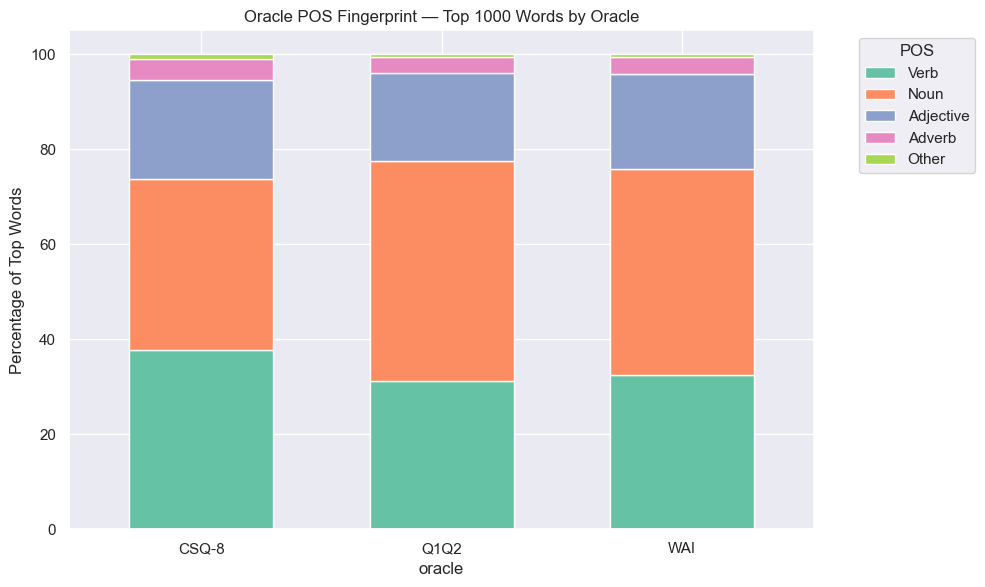

In [21]:
# --- POS Fingerprint: Part-of-speech distribution of each oracle's top words ---
# This reveals whether oracles preferentially surface verbs, nouns, adjectives, etc.

TOP_N_POS = 1000

pos_rows = []
for oracle in Config.ORACLES:
    if oracle not in oracle_avg_scores:
        continue
    avg_scores = pd.Series(oracle_avg_scores[oracle])
    top_idx_pos = avg_scores.nlargest(TOP_N_POS).index
    top_words_list = word_scores.loc[top_idx_pos, "word"].tolist()

    tagged = nltk.pos_tag(top_words_list)
    for word, tag in tagged:
        pos_rows.append({"oracle": oracle, "word": word,
                         "pos_tag": tag, "pos_coarse": coarse_pos(tag)})

pos_df = pd.DataFrame(pos_rows)

# Compute POS distribution per oracle
pos_dist = pos_df.groupby(["oracle", "pos_coarse"]).size().unstack(fill_value=0)
pos_pct = pos_dist.div(pos_dist.sum(axis=1), axis=0) * 100
pos_pct = pos_pct.reindex(columns=[c for c in POS_ORDER if c in pos_pct.columns], fill_value=0)

print(f"POS Distribution (%) per Oracle (Top {TOP_N_POS} words):")
display(pos_pct.round(1))

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
pos_pct.plot(kind="bar", stacked=True, ax=ax,
             color=sns.color_palette("Set2", len(pos_pct.columns)), width=0.6)
ax.set_ylabel("Percentage of Top Words")
ax.set_title(f"Oracle POS Fingerprint \u2014 Top {TOP_N_POS} Words by Oracle")
ax.set_xticklabels(pos_pct.index, rotation=0)
ax.legend(title="POS", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. Strategic Shift & POS Analysis

For oracles with both L0 and L5 experiments, we compute per-word score differences:
`mean(L5 scores) - mean(L0 scores)`.

- **Positive shift ("Strategic")**: Words favored by the lookahead planner but not the greedy approach.
- **Negative shift ("Tactical")**: Words favored by the greedy approach but not the planner.

The **POS analysis** adds a linguistic lens: are strategic words predominantly verbs
(actions, planning) while tactical words are nouns (concrete concepts)?


Strategic Shift: Q1Q2 (L0: 6 iters, L5: 10 iters)


word,L0_mean,L5_mean,shift
silliness,-0.2211,-0.0915,0.1296
goofing,-0.2276,-0.1010,0.1266
goof,-0.2465,-0.1200,0.1265
comically,-0.2140,-0.0906,0.1234
levity,-0.2105,-0.0877,0.1228
punchline,-0.1970,-0.0776,0.1194
goddammit,-0.1967,-0.0807,0.1160
improbable,-0.1354,-0.0201,0.1153
whoops,-0.1607,-0.0466,0.1140
whims,-0.1338,-0.0202,0.1137


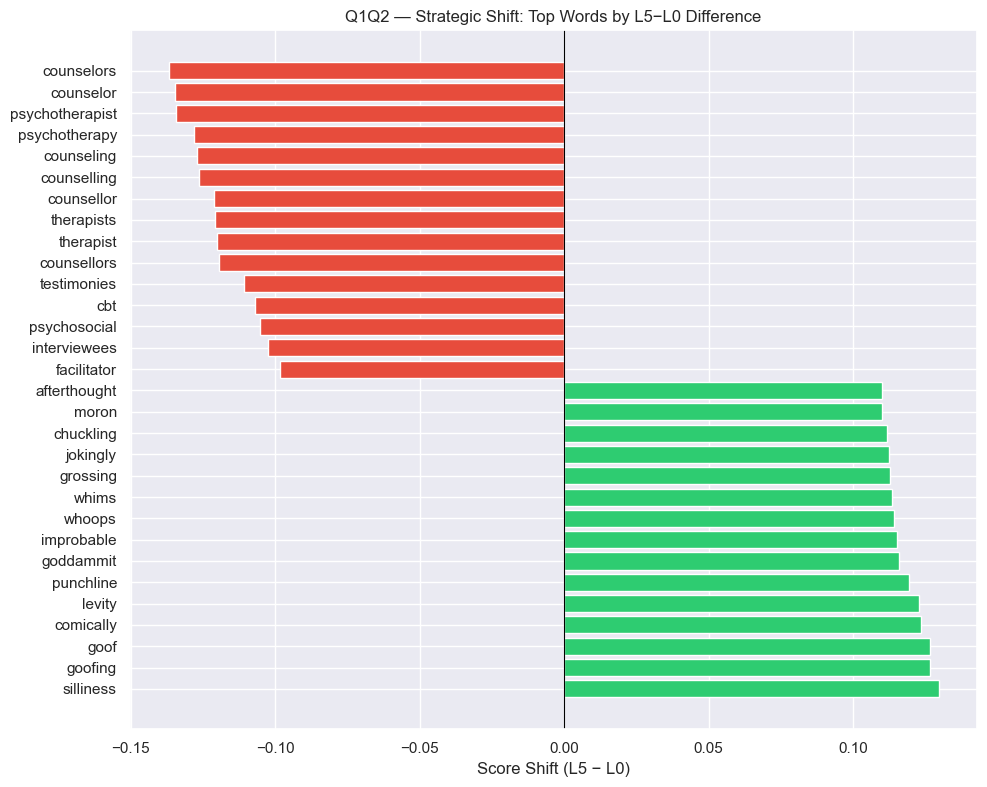

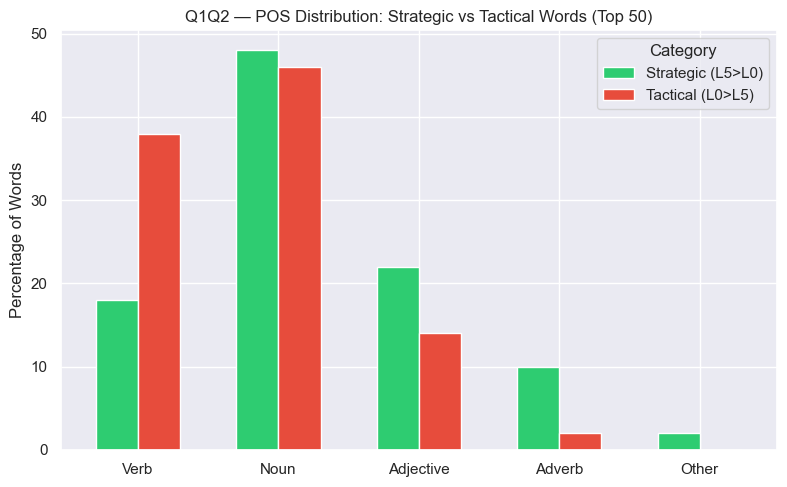


CSQ-8: Skipping — missing L0 or L5 data

Strategic Shift: WAI (L0: 6 iters, L5: 1 iters)


word,L0_mean,L5_mean,shift
unsupported,-0.0705,0.0870,0.1575
unhelpful,-0.1033,0.0459,0.1492
divorcing,-0.0584,0.0752,0.1336
disapproved,-0.1577,-0.0264,0.1313
disengage,-0.0180,0.1053,0.1233
futile,-0.0663,0.0560,0.1223
unsuitable,-0.0850,0.0313,0.1163
misplaced,-0.1173,-0.0098,0.1075
useless,-0.1095,-0.0025,0.1070
divorce,-0.0211,0.0855,0.1066


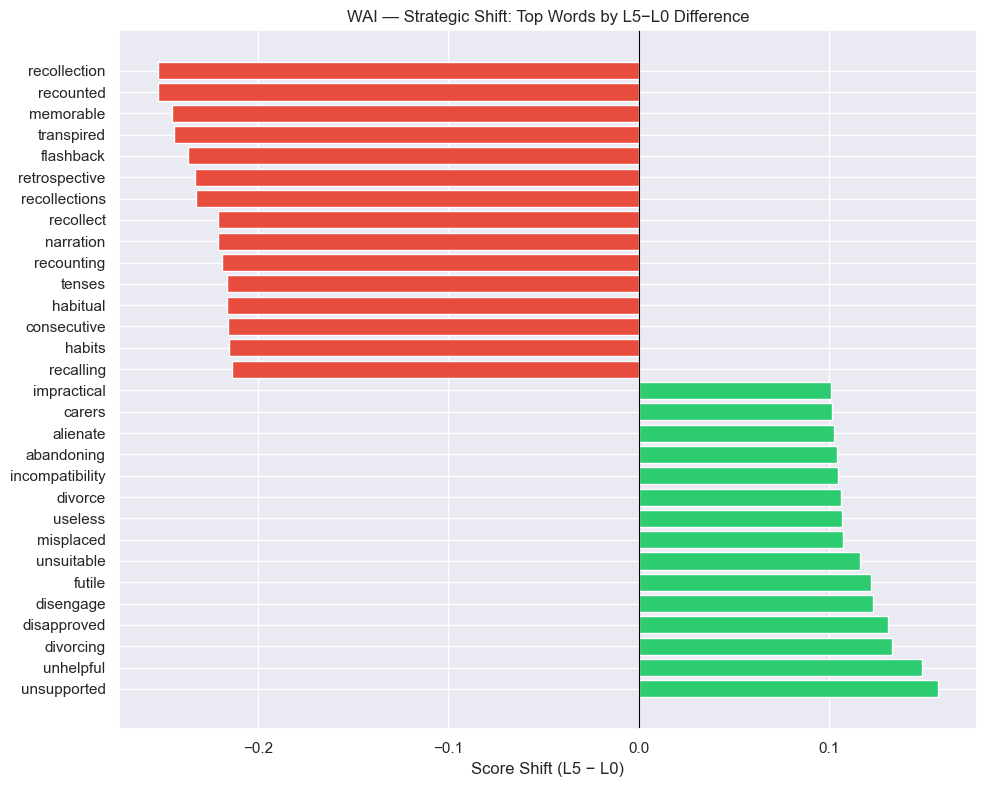

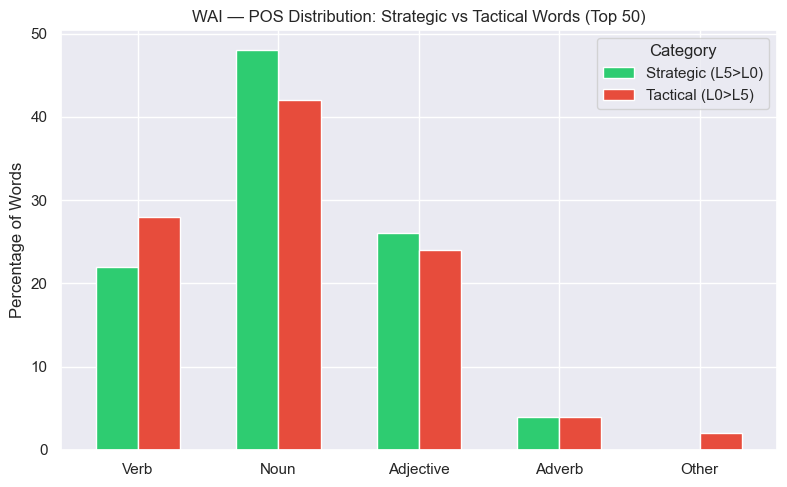

In [22]:
for oracle in Config.ORACLES:
    l0_cols = [col for col in word_scores.columns
               if col.startswith(f"{oracle}_L0_")
               and col not in ("word", "mean_score", "std_score", "TOTAL_COMBINED")]
    l5_cols = [col for col in word_scores.columns
               if col.startswith(f"{oracle}_L5_")
               and col not in ("word", "mean_score", "std_score", "TOTAL_COMBINED")]

    if not l0_cols or not l5_cols:
        print(f"\n{oracle}: Skipping \u2014 missing L0 or L5 data")
        continue

    print(f"\n{'='*60}")
    print(f"Strategic Shift: {oracle} (L0: {len(l0_cols)} iters, L5: {len(l5_cols)} iters)")
    print(f"{'='*60}")

    l0_mean = word_scores[l0_cols].mean(axis=1)
    l5_mean = word_scores[l5_cols].mean(axis=1)
    shift = l5_mean - l0_mean

    shift_df = pd.DataFrame({
        "word": word_scores["word"],
        "L0_mean": l0_mean,
        "L5_mean": l5_mean,
        "shift": shift
    })

    top_strategic = shift_df.nlargest(15, "shift")
    top_tactical = shift_df.nsmallest(15, "shift")

    # Display tables side by side
    display(HTML(f"""
    <div style="display: flex; gap: 20px;">
        <div style="flex: 1;">
            <h4>{oracle} \u2014 Top 15 "Strategic" Words (L5 > L0)</h4>
            {top_strategic[["word", "L0_mean", "L5_mean", "shift"]].to_html(index=False, float_format="%.4f")}
        </div>
        <div style="flex: 1;">
            <h4>{oracle} \u2014 Top 15 "Tactical" Words (L0 > L5)</h4>
            {top_tactical[["word", "L0_mean", "L5_mean", "shift"]].to_html(index=False, float_format="%.4f")}
        </div>
    </div>
    """))

    # Diverging horizontal bar chart
    top_n = 15
    combined = pd.concat([top_strategic.head(top_n), top_tactical.head(top_n)])
    combined = combined.sort_values("shift")

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ["#e74c3c" if s < 0 else "#2ecc71" for s in combined["shift"]]
    ax.barh(combined["word"], combined["shift"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Score Shift (L5 \u2212 L0)")
    ax.set_title(f"{oracle} \u2014 Strategic Shift: Top Words by L5\u2212L0 Difference")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # --- POS analysis of strategic vs tactical words ---
    # Tag the top 50 strategic and tactical words and compare their POS distributions
    n_pos_shift = 50
    strategic_words = shift_df.nlargest(n_pos_shift, "shift")["word"].tolist()
    tactical_words = shift_df.nsmallest(n_pos_shift, "shift")["word"].tolist()

    strategic_tagged = nltk.pos_tag(strategic_words)
    tactical_tagged = nltk.pos_tag(tactical_words)

    strategic_pos = pd.Series([coarse_pos(t) for _, t in strategic_tagged]).value_counts()
    tactical_pos = pd.Series([coarse_pos(t) for _, t in tactical_tagged]).value_counts()

    pos_shift_df = pd.DataFrame({
        "Strategic (L5>L0)": strategic_pos,
        "Tactical (L0>L5)": tactical_pos
    }).reindex(POS_ORDER).fillna(0)

    # Normalize to percentages
    pos_shift_pct = pos_shift_df.div(pos_shift_df.sum()) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    pos_shift_pct.plot(kind="bar", ax=ax, width=0.6,
                       color=["#2ecc71", "#e74c3c"])
    ax.set_ylabel("Percentage of Words")
    ax.set_title(f"{oracle} \u2014 POS Distribution: Strategic vs Tactical Words (Top {n_pos_shift})")
    ax.set_xticklabels(POS_ORDER, rotation=0)
    ax.legend(title="Category")
    plt.tight_layout()
    plt.show()

## 13. MI Domain-Specific Projection

Curated dictionaries of **Motivational Interviewing (MI)** terms are projected onto
each oracle's preference direction. This reveals whether oracles differentially value:
- **Change Talk**: Client language indicating readiness to change (e.g., "ready", "willing", "commit").
- **Sustain Talk**: Client language indicating resistance (e.g., "difficult", "stuck", "impossible").
- **Therapist Actions**: Counselor behaviors (e.g., "listen", "reflect", "validate").

A well-aligned oracle should score Change Talk and Therapist Actions positively and
Sustain Talk negatively (or near zero).

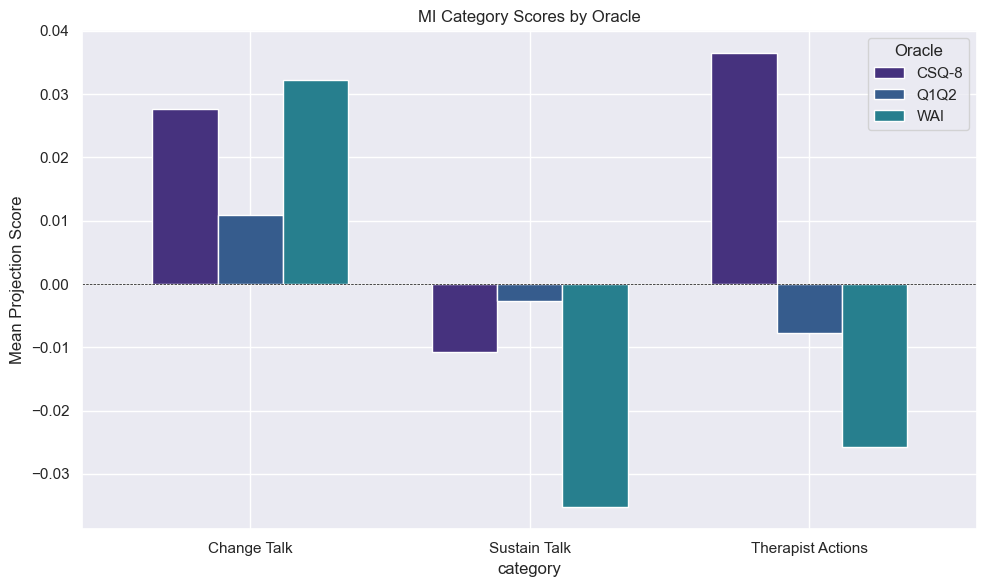

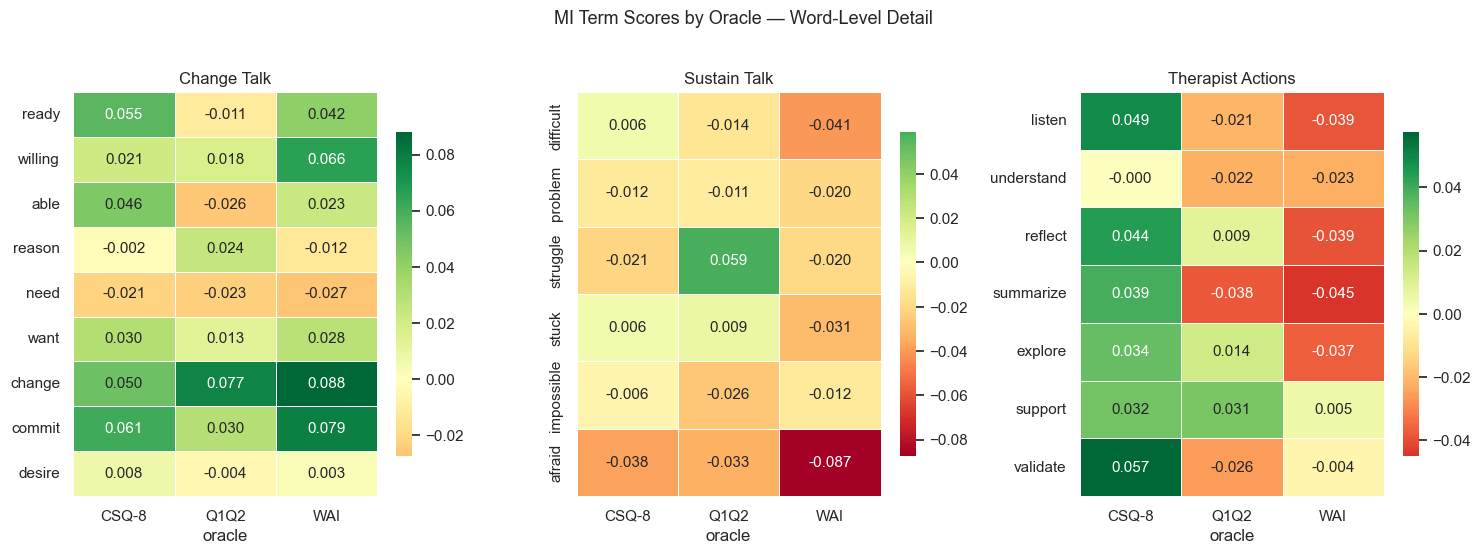

All MI terms found in vocabulary.


In [23]:
MI_CATEGORIES = {
    "Change Talk": ["ready", "willing", "able", "reason", "need", "want",
                    "change", "commit", "desire"],
    "Sustain Talk": ["difficult", "problem", "struggle", "stuck",
                     "impossible", "afraid"],
    "Therapist Actions": ["listen", "understand", "reflect", "summarize",
                          "explore", "support", "validate"],
}

# Build category x oracle score matrix
rows = []
detail_rows = []

for cat, words in MI_CATEGORIES.items():
    for oracle in Config.ORACLES:
        if oracle not in oracle_avg_scores:
            continue
        scores_for_cat = []
        for w in words:
            if w in word_to_idx:
                idx = word_to_idx[w]
                score = oracle_avg_scores[oracle][idx]
                scores_for_cat.append(score)
                detail_rows.append({"category": cat, "oracle": oracle,
                                    "word": w, "score": score})
        if scores_for_cat:
            rows.append({"category": cat, "oracle": oracle,
                         "mean_score": np.mean(scores_for_cat)})

cat_oracle_df = pd.DataFrame(rows)
detail_df = pd.DataFrame(detail_rows)

# 1. Grouped bar chart: category mean scores by oracle
cat_names = list(MI_CATEGORIES.keys())
fig, ax = plt.subplots(figsize=(10, 6))
pivot = cat_oracle_df.pivot(index="category", columns="oracle", values="mean_score")
pivot = pivot.reindex(cat_names)
pivot.plot(kind="bar", ax=ax, width=0.7)
ax.set_ylabel("Mean Projection Score")
ax.set_title("MI Category Scores by Oracle")
ax.set_xticklabels(cat_names, rotation=0)
ax.legend(title="Oracle")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

# 2. Per-category word-level heatmaps
n_cats = len(cat_names)
fig, axes = plt.subplots(1, n_cats,
                          figsize=(5 * n_cats,
                                   max(4, max(len(v) for v in MI_CATEGORIES.values()) * 0.6)))
for ax, cat in zip(axes, cat_names):
    cat_detail = detail_df[detail_df["category"] == cat].pivot(
        index="word", columns="oracle", values="score"
    )
    ordered_words = [w for w in MI_CATEGORIES[cat] if w in cat_detail.index]
    cat_detail = cat_detail.reindex(ordered_words)

    sns.heatmap(cat_detail, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{cat}")
    ax.set_ylabel("")

plt.suptitle("MI Term Scores by Oracle \u2014 Word-Level Detail", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 3. Report missing words
all_mi_words = set(w for words in MI_CATEGORIES.values() for w in words)
missing = all_mi_words - set(word_to_idx.keys())
if missing:
    print(f"Warning: {len(missing)} MI words not in vocabulary: {missing}")
else:
    print("All MI terms found in vocabulary.")

## 14. Evolutionary Trajectory & POS Trajectory

Tracks how preference semantics evolve across DPO iterations.

### Word Score Trajectory
For representative words (top 10 positive + top 10 negative by global mean score),
we plot their projection score across iterations within each experiment group.
This reveals whether certain concepts become more or less "preferred" as training progresses.

### POS Trajectory
For each iteration, we POS-tag the top-N words and track how the POS composition
shifts over time. For example: do verbs (actions) become more dominant in later
iterations, suggesting the model increasingly values behavioral language?

Positive representatives: ['motivating', 'motivator', 'motivates', 'motivate', 'motivation', 'motivational', 'dieting', 'motivated', 'fitness', 'inspirations']
Negative representatives: ['farce', 'asshole', 'douchebag', 'assholes', 'whore', 'buffoon', 'stfu', 'hypocrisy', 'horseshit', 'arsehole']


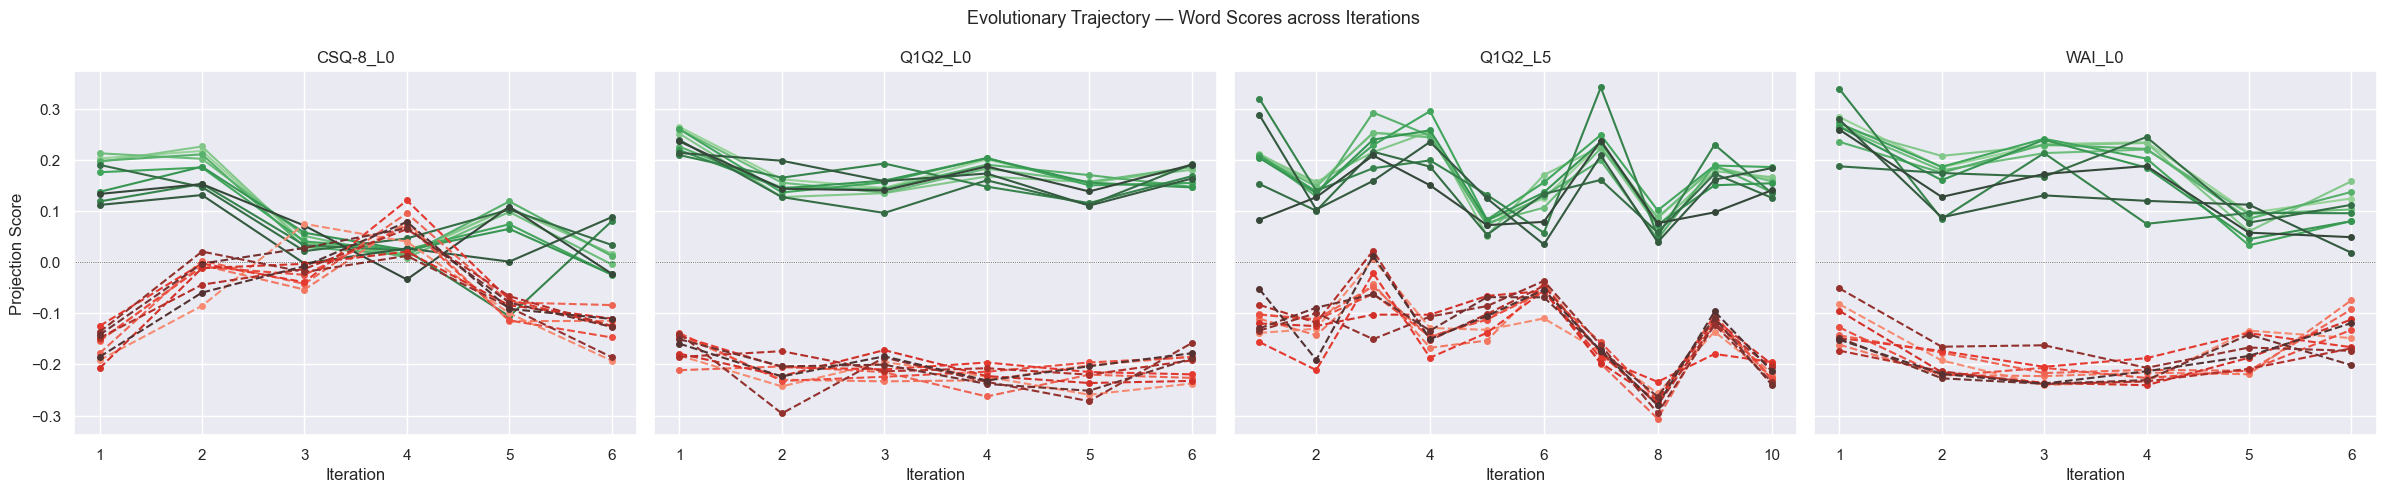

In [24]:
# --- Word Score Trajectory ---
n_rep = 10
rep_positive = word_scores.nlargest(n_rep, "mean_score")["word"].tolist()
rep_negative = word_scores.nsmallest(n_rep, "mean_score")["word"].tolist()
rep_words = rep_positive + rep_negative
print(f"Positive representatives: {rep_positive}")
print(f"Negative representatives: {rep_negative}")

# Build trajectory data
traj_rows = []
for exp, members in sorted(experiment_datasets.items()):
    if len(members) < 2:
        continue
    for label in members:
        iteration = label.rsplit("_", 1)[-1]
        iter_num = int(iteration[1:])
        for w in rep_words:
            if w in word_to_idx:
                idx = word_to_idx[w]
                score = word_scores.loc[idx, label]
                traj_rows.append({
                    "experiment": exp, "iteration": iteration,
                    "iter_num": iter_num, "word": w, "score": score,
                    "valence": "positive" if w in rep_positive else "negative"
                })

traj_df = pd.DataFrame(traj_rows)

# Faceted line plot: one subplot per experiment group
exps_with_data = sorted(traj_df["experiment"].unique())
n_exps = len(exps_with_data)
fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 5), sharey=True)
if n_exps == 1:
    axes = [axes]

pos_palette = sns.color_palette("Greens_d", n_rep)
neg_palette = sns.color_palette("Reds_d", n_rep)
word_colors = {w: c for w, c in zip(rep_positive, pos_palette)}
word_colors.update({w: c for w, c in zip(rep_negative, neg_palette)})

for ax, exp in zip(axes, exps_with_data):
    exp_data = traj_df[traj_df["experiment"] == exp]
    for w in rep_words:
        w_data = exp_data[exp_data["word"] == w].sort_values("iter_num")
        if w_data.empty:
            continue
        linestyle = "-" if w in rep_positive else "--"
        ax.plot(w_data["iter_num"], w_data["score"],
                marker="o", markersize=4, linewidth=1.5,
                label=w, color=word_colors[w], linestyle=linestyle)

    ax.set_title(exp)
    ax.set_xlabel("Iteration")
    if ax == axes[0]:
        ax.set_ylabel("Projection Score")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")

plt.suptitle("Evolutionary Trajectory \u2014 Word Scores across Iterations", fontsize=13)
plt.tight_layout()
plt.show()


POS Trajectory: CSQ-8_L0 (6 iterations)


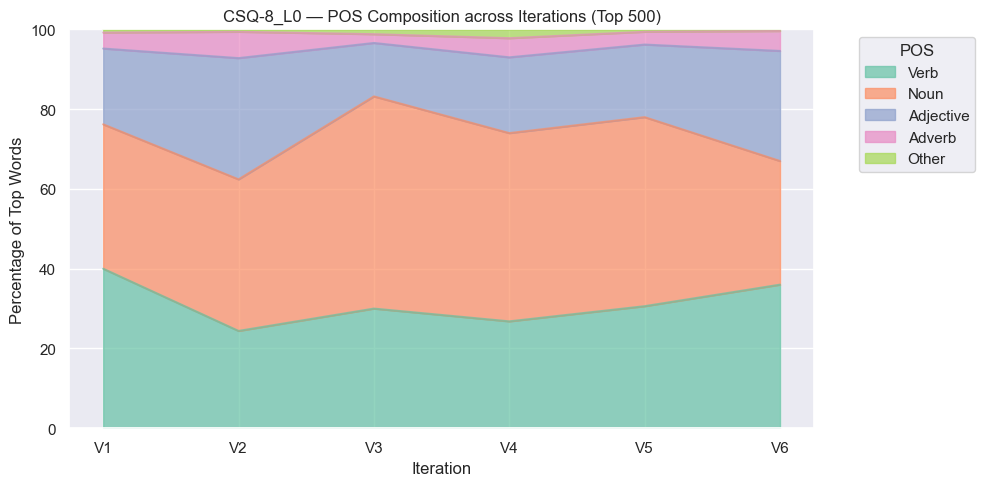

,Verb,Noun,Adjective,Adverb,Other
V1,40.0,36.2,19.0,4.0,0.8
V2,24.4,38.0,30.4,6.6,0.6
V3,30.0,53.2,13.4,2.2,1.2
V4,26.8,47.2,19.0,4.8,2.2
V5,30.6,47.4,18.2,3.2,0.6
V6,36.0,31.0,27.6,5.0,0.4



POS Trajectory: Q1Q2_L0 (6 iterations)


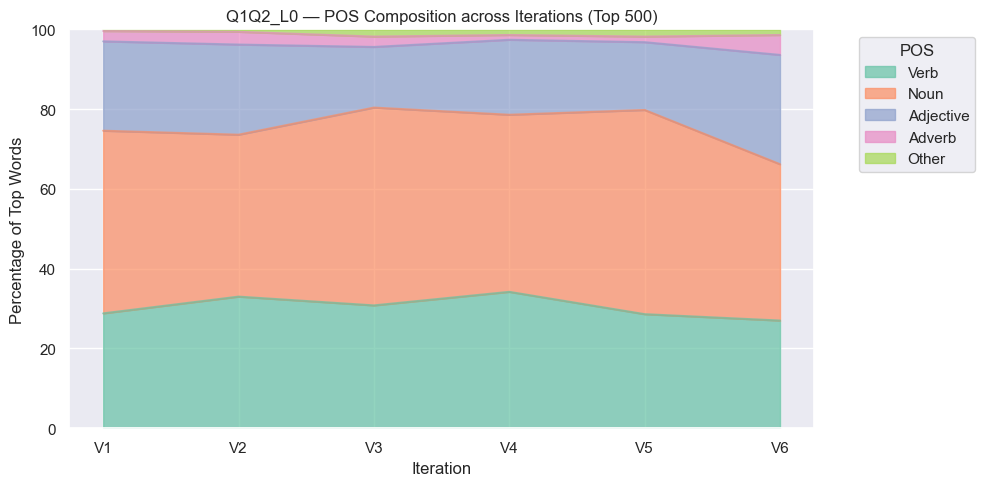

,Verb,Noun,Adjective,Adverb,Other
V1,28.8,45.8,22.4,2.6,0.4
V2,33.0,40.6,22.6,3.2,0.6
V3,30.8,49.6,15.2,2.6,1.8
V4,34.2,44.4,18.8,1.2,1.4
V5,28.6,51.2,17.0,1.4,1.8
V6,27.0,39.2,27.4,5.0,1.4



POS Trajectory: Q1Q2_L5 (10 iterations)


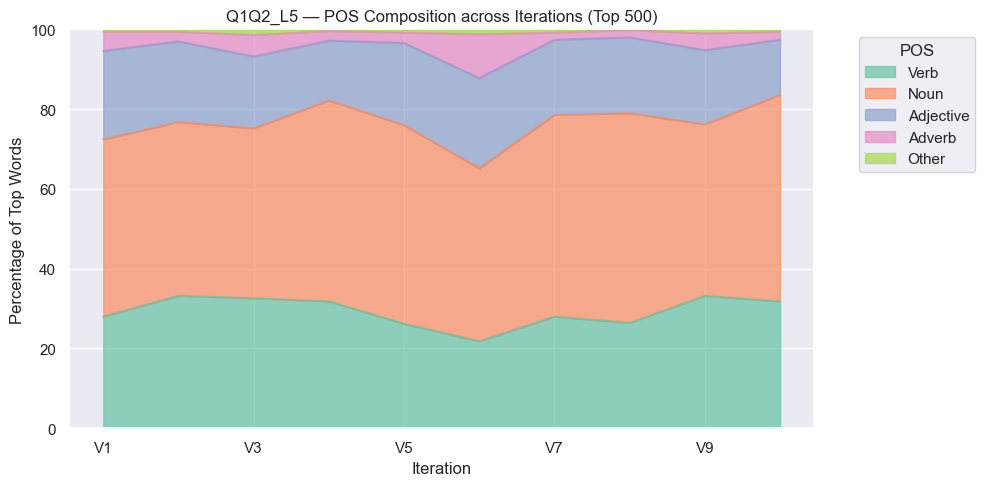

,Verb,Noun,Adjective,Adverb,Other
V1,28.0,44.4,22.2,4.8,0.6
V2,33.2,43.6,20.2,2.4,0.6
V3,32.6,42.6,18.0,5.4,1.4
V4,31.8,50.4,15.0,2.4,0.4
V5,26.2,49.8,20.6,2.6,0.8
V6,21.8,43.4,22.6,11.0,1.2
V7,28.0,50.6,18.8,1.8,0.8
V8,26.4,52.6,19.0,1.8,0.2
V9,33.2,43.0,18.6,4.2,1.0
V10,31.8,51.8,13.8,2.0,0.6



POS Trajectory: WAI_L0 (6 iterations)


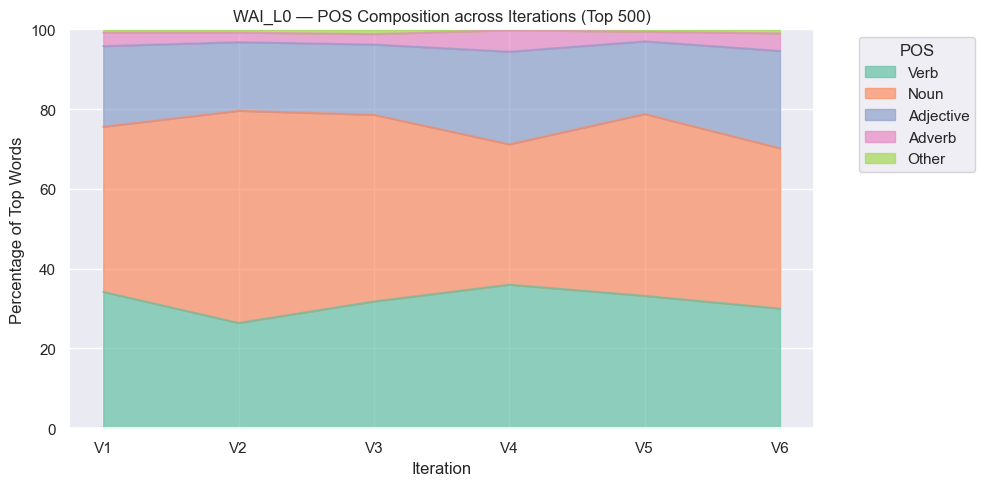

,Verb,Noun,Adjective,Adverb,Other
V1,34.2,41.4,20.2,3.4,0.8
V2,26.4,53.2,17.2,2.4,0.8
V3,31.8,46.8,17.6,2.6,1.2
V4,36.0,35.2,23.2,5.4,0.2
V5,33.2,45.6,18.2,2.4,0.6
V6,30.0,40.2,24.4,4.4,1.0


In [25]:
# --- POS Trajectory: how does POS composition of top words shift across iterations? ---
# For each iteration within each experiment, POS-tag the top-N words and compute
# the POS distribution. Plot as a stacked area chart to visualize the evolution.

TOP_N_POS_TRAJ = 500  # Top N words per iteration to analyze

for exp, members in sorted(experiment_datasets.items()):
    if len(members) < 2:
        continue

    print(f"\n{'='*60}")
    print(f"POS Trajectory: {exp} ({len(members)} iterations)")
    print(f"{'='*60}")

    iter_labels = []
    pos_pct_per_iter = []

    for label in members:
        iteration = label.rsplit("_", 1)[-1]
        iter_labels.append(iteration)

        # Get top words for this specific iteration's preference direction
        scores = pd.Series(word_scores[label].values)
        top_idx_iter = scores.nlargest(TOP_N_POS_TRAJ).index
        top_words_iter = word_scores.loc[top_idx_iter, "word"].tolist()

        tagged = nltk.pos_tag(top_words_iter)
        pos_counts = pd.Series([coarse_pos(t) for _, t in tagged]).value_counts()
        pos_pct_iter = (pos_counts / pos_counts.sum() * 100).reindex(POS_ORDER).fillna(0)
        pos_pct_per_iter.append(pos_pct_iter)

    # Build DataFrame: rows=iterations, columns=POS categories
    pos_traj_df = pd.DataFrame(pos_pct_per_iter, index=iter_labels)

    # Stacked area chart
    fig, ax = plt.subplots(figsize=(10, 5))
    pos_traj_df.plot.area(ax=ax, stacked=True, alpha=0.7,
                          color=sns.color_palette("Set2", len(POS_ORDER)))
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Percentage of Top Words")
    ax.set_title(f"{exp} \u2014 POS Composition across Iterations (Top {TOP_N_POS_TRAJ})")
    ax.legend(title="POS", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

    # Also show the raw numbers as a table
    display(pos_traj_df.round(1))